Training Hunger Instinct Agent (Fixed)
----------------------------------------
TRAINING HUNGER INSTINCT AGENT
Training for 1000 episodes...
Grid: 8x8, Food: 3, Dangers: 2
Episode 100: Avg Reward = 11.04, Success Rate = 40.0%, Exploration = 0.606


Episode 200: Avg Reward = 23.50, Success Rate = 61.0%, Exploration = 0.367


Episode 300: Avg Reward = 25.57, Success Rate = 66.0%, Exploration = 0.222
Episode 400: Avg Reward = 28.77, Success Rate = 73.0%, Exploration = 0.135


Episode 500: Avg Reward = 36.17, Success Rate = 80.0%, Exploration = 0.082
Episode 600: Avg Reward = 31.66, Success Rate = 75.0%, Exploration = 0.050


Episode 700: Avg Reward = 31.89, Success Rate = 72.0%, Exploration = 0.050


Episode 800: Avg Reward = 36.66, Success Rate = 78.0%, Exploration = 0.050


Episode 900: Avg Reward = 34.57, Success Rate = 75.0%, Exploration = 0.050
Episode 1000: Avg Reward = 35.44, Success Rate = 77.0%, Exploration = 0.050

TRAINING COMPLETE

Final Performance (last 100 episodes):
  Average Reward: 35.44
  Average Food Collected: 2.92
  Success Rate: 77.0%
  Average Steps per Episode: 48.9
  Final Exploration Rate: 0.050
  States learned: 392

Learning Progress (early vs late):
  Food: 1.04 -> 2.92
  Success: 40.0% -> 77.0%


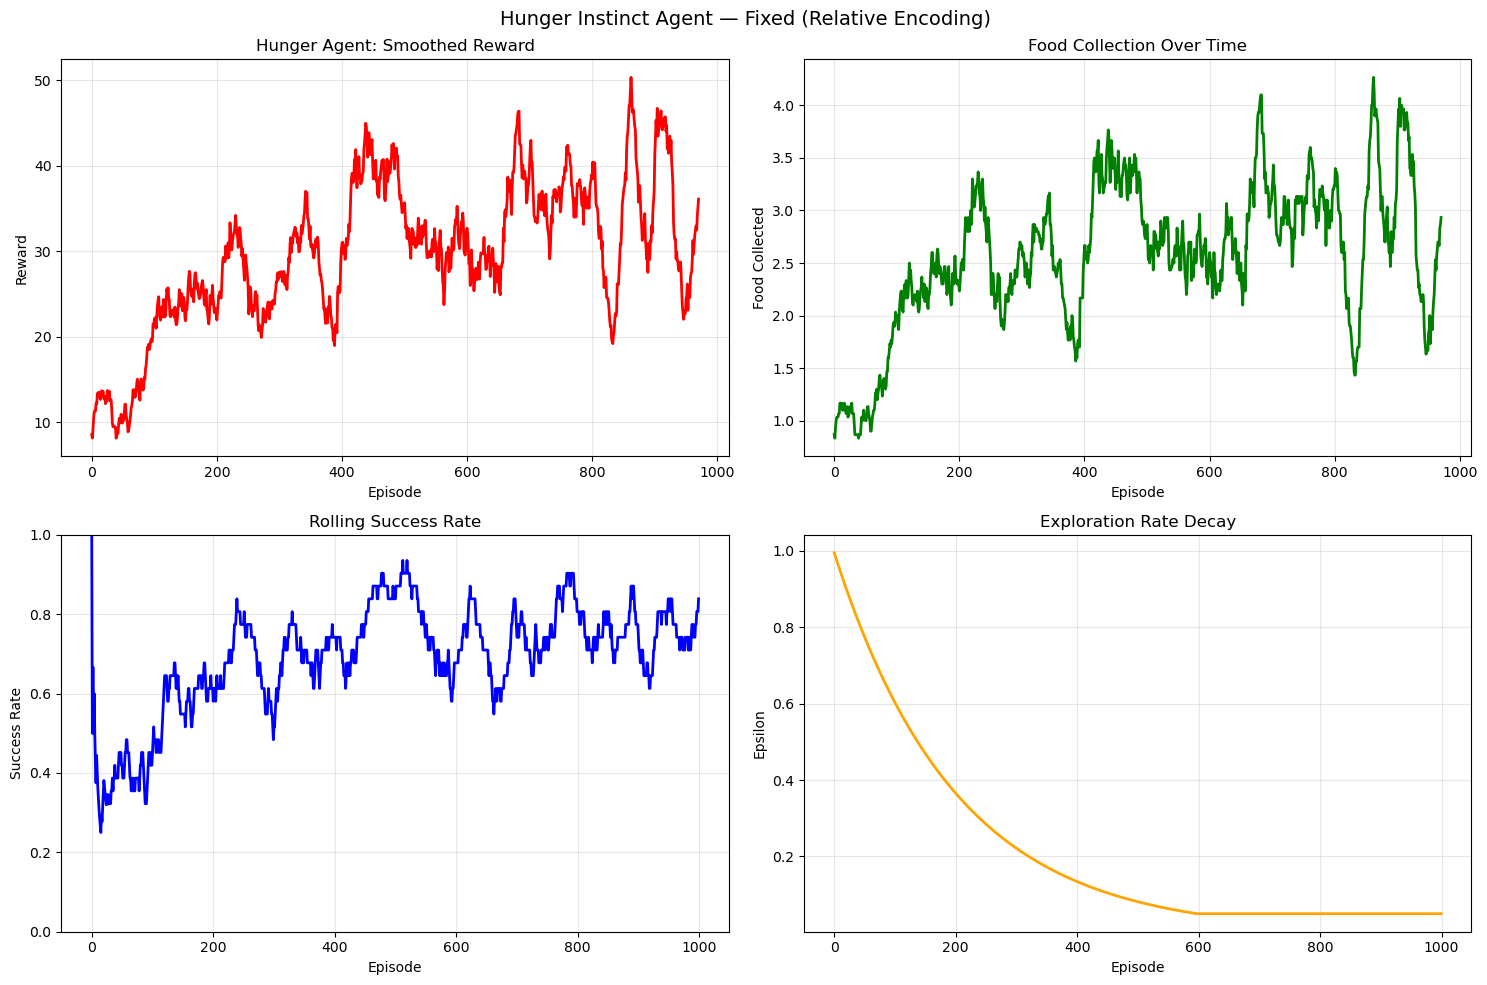


TESTING HUNGER INSTINCT AGENT

Test Episode 1:
------------------------------
  Step  0: Food=0, Reward=0.24
  Step 10: Food=0, Reward=0.24
  Step 20: Food=0, Reward=-0.26
  Step 30: Food=0, Reward=-0.26
  Step 40: Food=0, Reward=-0.26

  Total Reward: -2.50, Food: 0, Steps: 50, Danger: False
  Actions: {'Up': 25, 'Down': 24, 'Left': 1, 'Right': 0, 'Stay': 0}


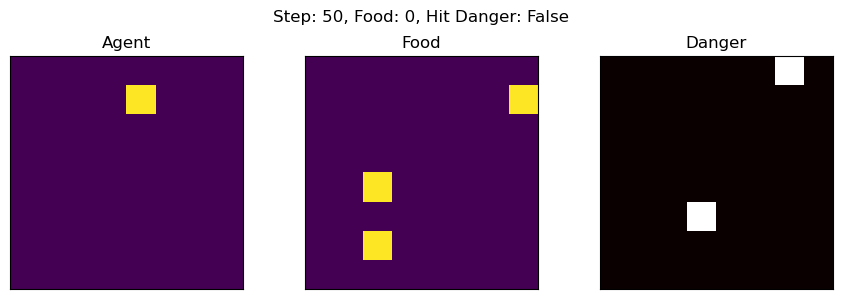


Test Episode 2:
------------------------------
  Step  0: Food=0, Reward=0.32
  Step 10: Food=5, Reward=6.63
  Step 20: Food=7, Reward=1.18
  Step 30: Food=10, Reward=6.23
  Step 40: Food=10, Reward=1.00

  Total Reward: 113.10, Food: 10, Steps: 50, Danger: False
  Actions: {'Up': 8, 'Down': 9, 'Left': 15, 'Right': 18, 'Stay': 0}


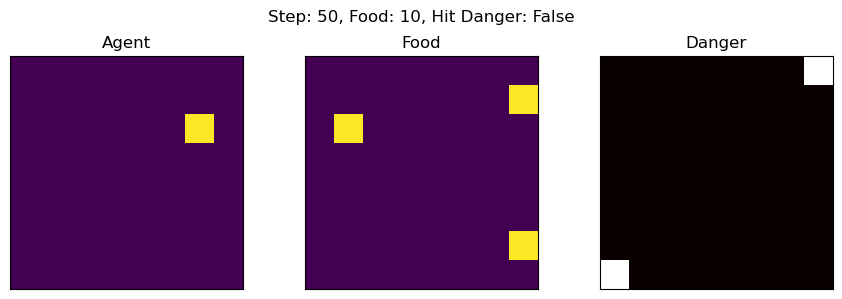


Test Episode 3:
------------------------------
  Step  0: Food=1, Reward=7.29
  Step 10: Food=4, Reward=6.36
  Step 20: Food=4, Reward=0.89
  Step 30: Food=4, Reward=0.71
  Step 40: Food=4, Reward=0.32

  Total Reward: 59.03, Food: 4, Steps: 50, Danger: False
  Actions: {'Up': 4, 'Down': 1, 'Left': 23, 'Right': 22, 'Stay': 0}


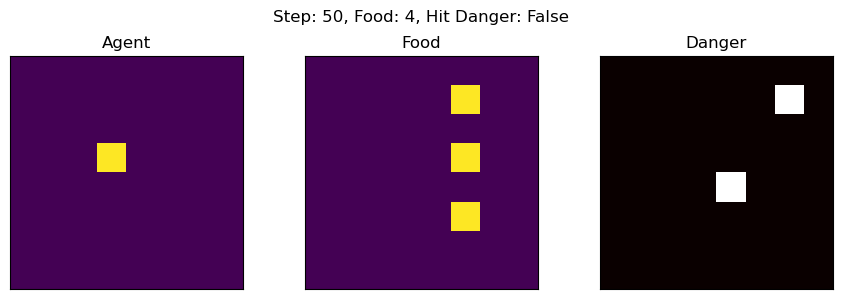


TEST SUMMARY
Average Reward: 56.54
Average Food Collected: 4.67
Success Rate: 66.7%
Model saved to hunger_agent_model.pkl


In [ ]:
# Import required libraries
import numpy as np
import random
from collections import defaultdict
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

# 1. Environment Class (Needed for the agent to interact with)
class HungerEnv(gym.Env):
    """A simplified 2D grid world focused on food collection for hunger instinct."""
    
    def __init__(self, grid_size=8, num_food=3, num_dangers=2):
        super(HungerEnv, self).__init__()
        
        self.grid_size = grid_size
        self.num_food = num_food
        self.num_dangers = num_dangers
        
        # Action space: 0=up, 1=down, 2=left, 3=right, 4=stay
        self.action_space = spaces.Discrete(5)
        
        # Observation space: agent position + food locations
        self.observation_space = spaces.Box(
            low=0, high=1, 
            shape=(grid_size, grid_size, 3),  # 3 channels: agent, food, danger
            dtype=np.float32
        )
        
        self.reset()
    
    def reset(self):
        """Reset the environment to initial state."""
        # Initialize empty grid
        self.grid = np.zeros((self.grid_size, self.grid_size, 3))
        
        # Place agent at random position
        self.agent_pos = np.random.randint(0, self.grid_size, size=2)
        self.grid[self.agent_pos[0], self.agent_pos[1], 0] = 1
        
        # Place food randomly
        self.food_positions = []
        for _ in range(self.num_food):
            pos = np.random.randint(0, self.grid_size, size=2)
            while np.array_equal(pos, self.agent_pos):
                pos = np.random.randint(0, self.grid_size, size=2)
            self.food_positions.append(pos)
            self.grid[pos[0], pos[1], 1] = 1
        
        # Place dangers randomly (smaller number for focus on hunger)
        self.danger_positions = []
        for _ in range(self.num_dangers):
            pos = np.random.randint(0, self.grid_size, size=2)
            while (np.array_equal(pos, self.agent_pos) or 
                   any(np.array_equal(pos, f) for f in self.food_positions)):
                pos = np.random.randint(0, self.grid_size, size=2)
            self.danger_positions.append(pos)
            self.grid[pos[0], pos[1], 2] = 1
        
        # Statistics
        self.steps_survived = 0
        self.food_collected = 0
        self.hit_danger = False
        
        return self.grid.copy()
    
    def step(self, action):
        """Take a step in the environment."""
        old_pos = self.agent_pos.copy()
        
        # Update agent position based on action
        if action == 0 and self.agent_pos[0] > 0:  # up
            self.agent_pos[0] -= 1
        elif action == 1 and self.agent_pos[0] < self.grid_size - 1:  # down
            self.agent_pos[0] += 1
        elif action == 2 and self.agent_pos[1] > 0:  # left
            self.agent_pos[1] -= 1
        elif action == 3 and self.agent_pos[1] < self.grid_size - 1:  # right
            self.agent_pos[1] += 1
        # action == 4: stay in place
        
        # Update grid
        self.grid[old_pos[0], old_pos[1], 0] = 0
        self.grid[self.agent_pos[0], self.agent_pos[1], 0] = 1
        
        # Check for food collection
        food_collected_this_step = 0
        for i, food_pos in enumerate(self.food_positions):
            if np.array_equal(self.agent_pos, food_pos):
                food_collected_this_step += 1
                self.food_collected += 1
                # Remove food and respawn
                self.grid[food_pos[0], food_pos[1], 1] = 0
                new_pos = np.random.randint(0, self.grid_size, size=2)
                while (self.grid[new_pos[0], new_pos[1], 0] == 1 or 
                       self.grid[new_pos[0], new_pos[1], 2] == 1):
                    new_pos = np.random.randint(0, self.grid_size, size=2)
                self.food_positions[i] = new_pos
                self.grid[new_pos[0], new_pos[1], 1] = 1
                break
        
        # Check for danger
        self.hit_danger = False
        for danger_pos in self.danger_positions:
            if np.array_equal(self.agent_pos, danger_pos):
                self.hit_danger = True
                break
        
        # Update statistics
        self.steps_survived += 1
        
        # Check if episode should end
        done = self.steps_survived >= 50 or self.hit_danger  # Shorter episodes
        
        # Base reward (environment provides minimal base reward)
        total_reward = food_collected_this_step * 0.5  # Small base food reward
        
        return self.grid.copy(), total_reward, done, {
            'food_collected': self.food_collected,
            'steps_survived': self.steps_survived,
            'hit_danger': self.hit_danger
        }
    
    def render(self, mode='human'):
        """Render the environment."""
        fig, axes = plt.subplots(1, 3, figsize=(9, 3))
        
        titles = ['Agent', 'Food', 'Danger']
        for i, ax in enumerate(axes):
            ax.imshow(self.grid[:, :, i], cmap='hot' if i == 2 else 'viridis')
            ax.set_title(titles[i])
            ax.set_xticks([])
            ax.set_yticks([])
        
        plt.suptitle(f'Step: {self.steps_survived}, Food: {self.food_collected}, '
                     f'Hit Danger: {self.hit_danger}')
        plt.tight_layout()
        plt.show()

# 2. Hunger Instinct Agent Class
class HungerInstinctAgent:
    """A Q-learning agent driven purely by hunger/food-seeking instinct."""
    
    def __init__(self, state_shape, num_actions, 
                 learning_rate=0.15, discount_factor=0.97, 
                 exploration_rate=1.0, exploration_decay=0.995):
        
        self.state_shape = state_shape
        self.num_actions = num_actions
        
        # Q-learning parameters
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate
        self.exploration_decay = exploration_decay
        self.min_exploration_rate = 0.05  # Keep some exploration for food discovery
        
        # Initialize Q-table as dictionary for sparse states
        self.q_table = defaultdict(lambda: np.zeros(num_actions))
        
        # Statistics tracking
        self.training_history = []
        self.last_food_count = 0
        
        # For reward computation
        self.food_collected_history = []
    
    def state_to_key(self, state):
        """Relative direction+distance encoding — avoids state space explosion."""
        agent_pos = np.argwhere(state[:, :, 0] == 1)[0]
        food_pos = np.argwhere(state[:, :, 1] == 1)
        danger_pos = np.argwhere(state[:, :, 2] == 1)

        def rel_key(target, src_pos):
            dr = int(target[0]) - int(src_pos[0])
            dc = int(target[1]) - int(src_pos[1])
            dist = abs(dr) + abs(dc)
            rd = 0 if dr == 0 else (1 if dr > 0 else -1)
            cd = 0 if dc == 0 else (1 if dc > 0 else -1)
            db = 1 if dist <= 1 else (2 if dist <= 3 else 3)
            return f"({rd},{cd},{db})"

        if len(food_pos) > 0:
            dists = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in food_pos]
            food_key = rel_key(food_pos[np.argmin(dists)], agent_pos)
        else:
            food_key = "fnone"

        if len(danger_pos) > 0:
            dists = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in danger_pos]
            danger_key = rel_key(danger_pos[np.argmin(dists)], agent_pos)
        else:
            danger_key = "dnone"

        return f"{food_key}|{danger_key}"
    def choose_action(self, state):
        """Choose an action using epsilon-greedy policy with food-focused exploration."""
        state_key = self.state_to_key(state)
        
        # Exploration: try random actions sometimes
        if random.random() < self.exploration_rate:
            # Bias exploration towards movement (not staying still)
            return random.randint(0, self.num_actions - 2)  # 0-3 only (no stay)
        
        # Exploitation: choose best action from Q-table
        return np.argmax(self.q_table[state_key])
    
    def compute_hunger_reward(self, env, action, info):
        """Compute reward specifically for hunger instinct."""
        reward = 0.0
        
        # 1. PRIMARY REWARD: Collecting food
        current_food = info['food_collected']
        
        # Immediate large reward when food is collected
        if current_food > self.last_food_count:
            reward += 5.0  # Strong positive signal for eating
            # Bonus if collected quickly
            if info['steps_survived'] < 10:
                reward += 2.0
        
        # Update last food count
        self.last_food_count = current_food
        
        # 2. SECONDARY REWARD: Moving toward food
        # Get current state information
        agent_channel = env.grid[:, :, 0]
        food_channel = env.grid[:, :, 1]
        
        # Find agent position
        agent_pos = np.argwhere(agent_channel == 1)[0]
        
        # Find all food positions
        food_positions = np.argwhere(food_channel == 1)
        
        if len(food_positions) > 0:
            distances = [abs(pos[0]-agent_pos[0]) + abs(pos[1]-agent_pos[1])
                        for pos in food_positions]
            min_distance = min(distances)
            max_dist = 2 * (env.grid_size - 1)
            # Proximity shaping: ~0 when far, ~0.4 when adjacent
            reward += (1.0 - min_distance / max_dist) * 0.4

        # 3. PENALTY: Staying still when food is available
        if action == 4 and len(food_positions) > 0:
            reward -= 0.3

        # 4. PENALTY: Hitting danger (interferes with food collection)
        if info.get('hit_danger', False):
            reward -= 3.0

        # 5. EFFICIENCY BONUS: High food collection rate
        if info['steps_survived'] > 5:
            collection_rate = info['food_collected'] / info['steps_survived']
            if collection_rate > 0.1:
                reward += collection_rate * 3.0

        # 6. TIME PENALTY: Small negative per step to encourage faster food finding
        reward -= 0.05

        # 7. STARVATION PENALTY: Long time without food
        if info['steps_survived'] > 20 and info['food_collected'] == 0:
            reward -= 0.5

        return reward

    def learn(self, state, action, reward, next_state, done):
        """Update Q-values using standard Q-learning."""
        state_key = self.state_to_key(state)
        next_state_key = self.state_to_key(next_state)

        current_q = self.q_table[state_key][action]

        if done:
            target = reward
        else:
            target = reward + self.discount_factor * np.max(self.q_table[next_state_key])

        self.q_table[state_key][action] = current_q + self.learning_rate * (target - current_q)

        if done:
            self.exploration_rate = max(
                self.min_exploration_rate,
                self.exploration_rate * self.exploration_decay
            )

    def train_episode(self, env, max_steps=50):
        """Train for one episode with hunger-focused learning."""
        state = env.reset()
        self.last_food_count = 0
        total_reward = 0
        steps = 0

        for step in range(max_steps):
            action = self.choose_action(state)
            next_state, base_reward, done, info = env.step(action)
            hunger_reward = self.compute_hunger_reward(env, action, info)
            self.learn(state, action, hunger_reward, next_state, done)
            total_reward += hunger_reward
            state = next_state
            steps = step + 1
            if done:
                break

        self.training_history.append({
            'total_reward': total_reward,
            'steps': steps,
            'exploration_rate': self.exploration_rate,
            'food_collected': info['food_collected'],
            'hit_danger': info.get('hit_danger', False),
            'success': 1 if info['food_collected'] > 0 and not info.get('hit_danger', False) else 0
        })

        return total_reward, steps

    def get_performance_metrics(self, last_n_episodes=50):
        if len(self.training_history) < last_n_episodes:
            last_n_episodes = len(self.training_history)
        recent = self.training_history[-last_n_episodes:]
        return {
            'avg_reward': np.mean([h['total_reward'] for h in recent]),
            'avg_food_collected': np.mean([h['food_collected'] for h in recent]),
            'success_rate': np.mean([h['success'] for h in recent]) * 100,
            'avg_steps': np.mean([h['steps'] for h in recent]),
            'exploration_rate': recent[-1]['exploration_rate'] if recent else self.exploration_rate
        }

    def save_model(self, filename):
        import pickle
        with open(filename, 'wb') as f:
            pickle.dump(dict(self.q_table), f)
        print(f"Model saved to {filename}")

    def load_model(self, filename):
        import pickle
        with open(filename, 'rb') as f:
            loaded_dict = pickle.load(f)
            self.q_table = defaultdict(lambda: np.zeros(self.num_actions), loaded_dict)
        print(f"Model loaded from {filename}")


# Training Function
def train_hunger_agent(num_episodes=1000, show_progress=True):
    env = HungerEnv(grid_size=8, num_food=3, num_dangers=2)
    agent = HungerInstinctAgent(
        state_shape=env.observation_space.shape,
        num_actions=env.action_space.n,
        learning_rate=0.15,
        discount_factor=0.97,
        exploration_rate=1.0,
        exploration_decay=0.995
    )

    print("=" * 60)
    print("TRAINING HUNGER INSTINCT AGENT")
    print("=" * 60)
    print(f"Training for {num_episodes} episodes...")
    print(f"Grid: {env.grid_size}x{env.grid_size}, Food: {env.num_food}, Dangers: {env.num_dangers}")

    episode_rewards = []
    success_rates = []

    for episode in range(num_episodes):
        reward, steps = agent.train_episode(env)
        episode_rewards.append(reward)
        if agent.training_history:
            success_rates.append(agent.training_history[-1]['success'])

        if show_progress and (episode + 1) % 100 == 0:
            recent_rewards = episode_rewards[-100:]
            recent_success = success_rates[-100:] if len(success_rates) >= 100 else success_rates
            avg_reward = np.mean(recent_rewards)
            success_rate = np.mean(recent_success) * 100 if recent_success else 0
            print(f"Episode {episode + 1}: "
                  f"Avg Reward = {avg_reward:.2f}, "
                  f"Success Rate = {success_rate:.1f}%, "
                  f"Exploration = {agent.exploration_rate:.3f}")

    print("\n" + "=" * 60)
    print("TRAINING COMPLETE")
    print("=" * 60)
    metrics = agent.get_performance_metrics(100)
    print(f"\nFinal Performance (last 100 episodes):")
    print(f"  Average Reward: {metrics['avg_reward']:.2f}")
    print(f"  Average Food Collected: {metrics['avg_food_collected']:.2f}")
    print(f"  Success Rate: {metrics['success_rate']:.1f}%")
    print(f"  Average Steps per Episode: {metrics['avg_steps']:.1f}")
    print(f"  Final Exploration Rate: {metrics['exploration_rate']:.3f}")
    print(f"  States learned: {len(agent.q_table)}")

    if len(agent.training_history) >= 200:
        early = agent.training_history[:100]
        late = agent.training_history[-100:]
        print(f"\nLearning Progress (early vs late):")
        print(f"  Food: {np.mean([h['food_collected'] for h in early]):.2f} -> "
              f"{np.mean([h['food_collected'] for h in late]):.2f}")
        print(f"  Success: {np.mean([h['success'] for h in early])*100:.1f}% -> "
              f"{np.mean([h['success'] for h in late])*100:.1f}%")

    return agent, env, episode_rewards


def visualize_hunger_learning(agent, episode_rewards):
    if not agent.training_history:
        return

    plt.figure(figsize=(15, 10))
    window = 30

    plt.subplot(2, 2, 1)
    smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    plt.plot(smoothed, color='red', linewidth=2)
    plt.title('Hunger Agent: Smoothed Reward')
    plt.xlabel('Episode'); plt.ylabel('Reward'); plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    food = [h['food_collected'] for h in agent.training_history]
    smoothed_food = np.convolve(food, np.ones(window)/window, mode='valid')
    plt.plot(smoothed_food, color='green', linewidth=2)
    plt.title('Food Collection Over Time')
    plt.xlabel('Episode'); plt.ylabel('Food Collected'); plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    success = [h['success'] for h in agent.training_history]
    rolling = [np.mean(success[max(0,i-window):i+1]) for i in range(len(success))]
    plt.plot(rolling, color='blue', linewidth=2)
    plt.title('Rolling Success Rate')
    plt.xlabel('Episode'); plt.ylabel('Success Rate'); plt.ylim(0, 1); plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 4)
    plt.plot([h['exploration_rate'] for h in agent.training_history], color='orange', linewidth=2)
    plt.title('Exploration Rate Decay')
    plt.xlabel('Episode'); plt.ylabel('Epsilon'); plt.grid(True, alpha=0.3)

    plt.suptitle('Hunger Instinct Agent — Fixed (Relative Encoding)', fontsize=14)
    plt.tight_layout()
    plt.show()


def test_hunger_agent(agent, env=None, num_episodes=3, render=True):
    if env is None:
        env = HungerEnv(grid_size=8, num_food=3, num_dangers=2)

    print("\n" + "=" * 60)
    print("TESTING HUNGER INSTINCT AGENT")
    print("=" * 60)

    test_results = {'total_rewards': [], 'food_collected': [], 'steps': [], 'success': []}

    for episode in range(num_episodes):
        state = env.reset()
        agent.last_food_count = 0
        total_reward = 0
        done = False
        step = 0
        action_history = []

        print(f"\nTest Episode {episode + 1}:")
        print("-" * 30)

        while not done and step < 50:
            orig_eps = agent.exploration_rate
            agent.exploration_rate = 0.0
            action = agent.choose_action(state)
            agent.exploration_rate = orig_eps
            action_history.append(action)
            next_state, _, done, info = env.step(action)
            hunger_reward = agent.compute_hunger_reward(env, action, info)
            total_reward += hunger_reward
            if render and step % 10 == 0:
                print(f"  Step {step:2d}: Food={info['food_collected']}, Reward={hunger_reward:.2f}")
            state = next_state
            step += 1

        print(f"\n  Total Reward: {total_reward:.2f}, Food: {info['food_collected']}, "
              f"Steps: {step}, Danger: {info.get('hit_danger', False)}")
        action_names = ['Up', 'Down', 'Left', 'Right', 'Stay']
        print(f"  Actions: {dict(zip(action_names, [action_history.count(i) for i in range(5)]))}")

        test_results['total_rewards'].append(total_reward)
        test_results['food_collected'].append(info['food_collected'])
        test_results['steps'].append(step)
        test_results['success'].append(1 if info['food_collected'] > 0 else 0)

        if render:
            env.render()

    print("\n" + "=" * 60)
    print("TEST SUMMARY")
    print("=" * 60)
    print(f"Average Reward: {np.mean(test_results['total_rewards']):.2f}")
    print(f"Average Food Collected: {np.mean(test_results['food_collected']):.2f}")
    print(f"Success Rate: {np.mean(test_results['success']) * 100:.1f}%")
    return test_results


# Main Execution
print("Training Hunger Instinct Agent (Fixed)")
print("-" * 40)
hunger_agent, env, rewards = train_hunger_agent(num_episodes=1000, show_progress=True)
visualize_hunger_learning(hunger_agent, rewards)
test_results = test_hunger_agent(hunger_agent, env, num_episodes=3, render=True)
hunger_agent.save_model("hunger_agent_model.pkl")


Example 1: Training Pure Exploration Instinct Agent
----------------------------------------
TRAINING PURE EXPLORATION INSTINCT AGENT
Training for 800 episodes...
Grid: 10x10, Obstacles: 5, Landmarks: 3


Episode 50: Avg Reward = 294.28, Avg Exploration = 36.4%, Exploration Rate = 0.740
Episode 100: Avg Reward = 300.87, Avg Exploration = 37.4%, Exploration Rate = 0.548
Episode 150: Avg Reward = 318.11, Avg Exploration = 39.2%, Exploration Rate = 0.405


Episode 200: Avg Reward = 313.22, Avg Exploration = 37.9%, Exploration Rate = 0.300
Episode 250: Avg Reward = 309.77, Avg Exploration = 36.8%, Exploration Rate = 0.222
Episode 300: Avg Reward = 325.06, Avg Exploration = 38.5%, Exploration Rate = 0.164
Episode 350: Avg Reward = 317.70, Avg Exploration = 36.9%, Exploration Rate = 0.122


Episode 400: Avg Reward = 320.34, Avg Exploration = 36.2%, Exploration Rate = 0.100
Episode 450: Avg Reward = 303.11, Avg Exploration = 33.9%, Exploration Rate = 0.100
Episode 500: Avg Reward = 305.24, Avg Exploration = 34.2%, Exploration Rate = 0.100
Episode 550: Avg Reward = 311.14, Avg Exploration = 35.3%, Exploration Rate = 0.100
Episode 600: Avg Reward = 281.64, Avg Exploration = 31.5%, Exploration Rate = 0.100
Episode 650: Avg Reward = 288.64, Avg Exploration = 33.2%, Exploration Rate = 0.100


Episode 700: Avg Reward = 259.31, Avg Exploration = 29.0%, Exploration Rate = 0.100
Episode 750: Avg Reward = 297.41, Avg Exploration = 33.1%, Exploration Rate = 0.100
Episode 800: Avg Reward = 325.52, Avg Exploration = 37.1%, Exploration Rate = 0.100

TRAINING COMPLETE

Final Performance (last 50 episodes):
  Average Reward: 325.52
  Average Unique Cells Visited: 37.1
  Average Exploration Percentage: 37.1%
  Success Rate (>50% explored): 12.0%
  Average Landmarks Discovered: 1.00
  Average Steps per Episode: 100.0
  Final Exploration Rate: 0.100

Learning Progress (early vs late):
  Reward: 294.28 → 325.52 (+10.6%)
  Exploration %: 36.4% → 37.1% (+0.7%)
  Unique Cells: 36.4 → 37.1 (+1.9%)


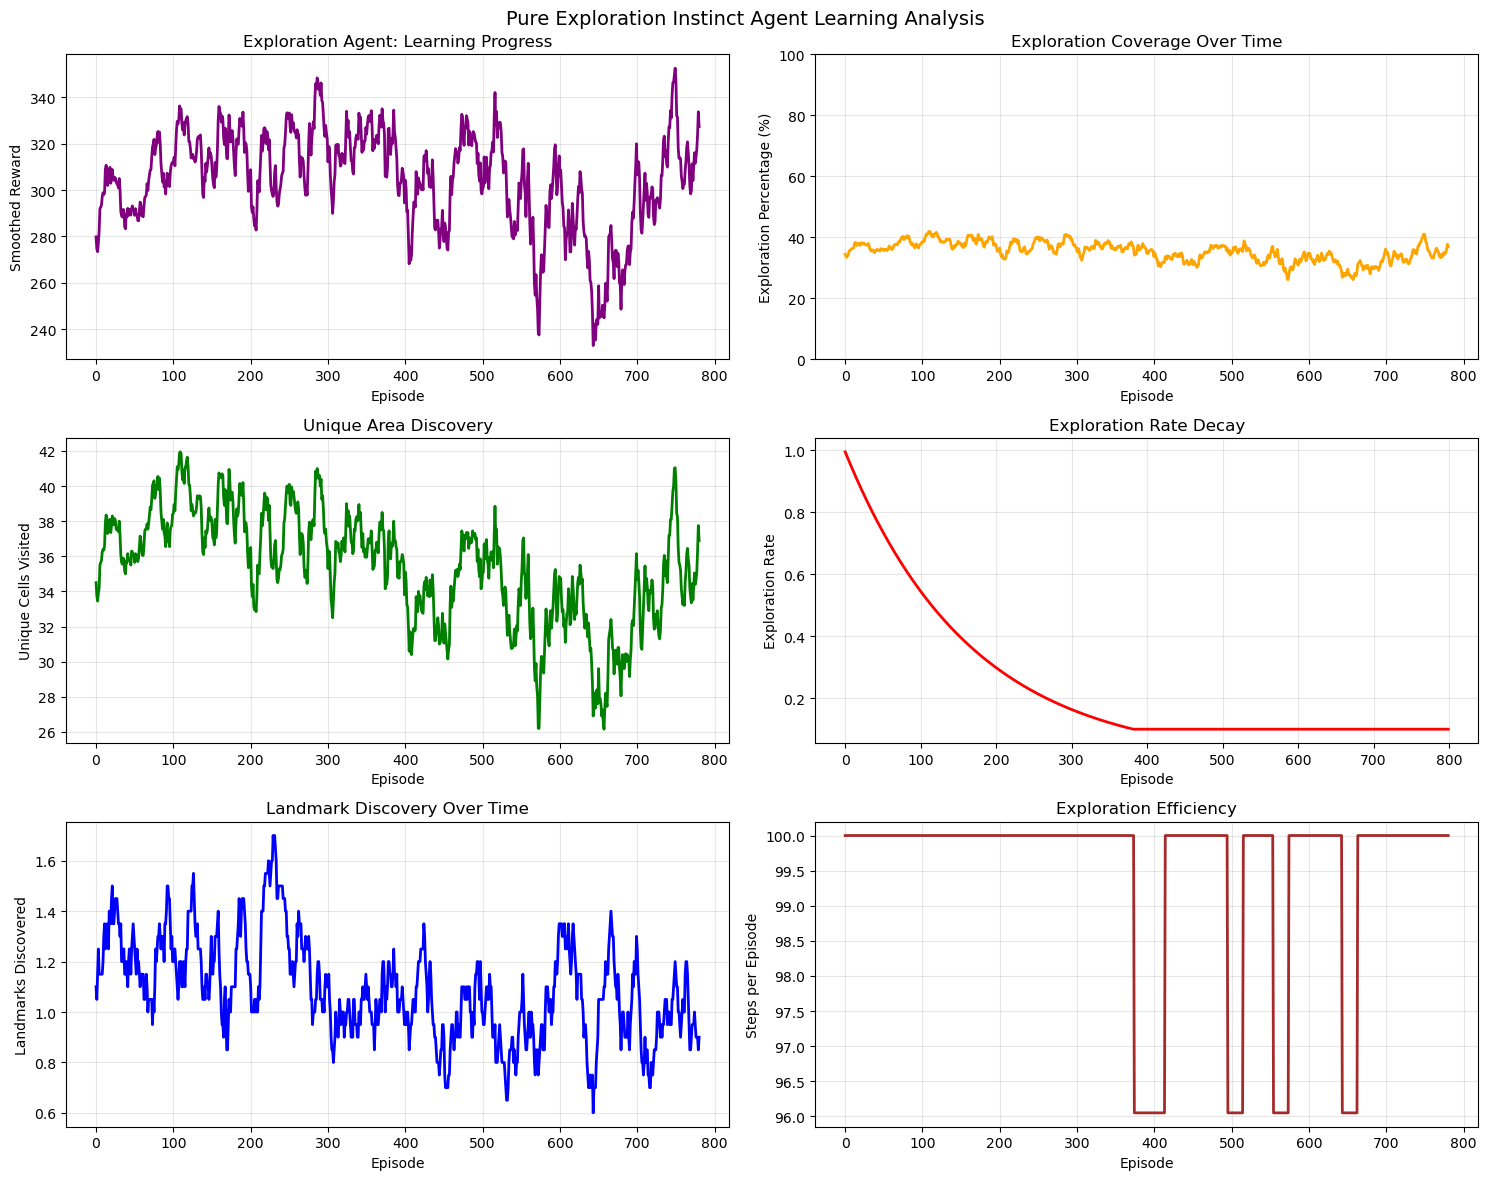


Q-table Statistics:
  Number of states learned: 621
  Sample state key: 00000000|e0
  Q-values for sample state: [65.53390593 52.22244462 76.00895903 63.93522177  0.        ]

TESTING PURE EXPLORATION INSTINCT AGENT

Test Episode 1:
------------------------------
  Step   0: Visited=  2, Explored=  2.0%, Landmarks=0
  Step  20: Visited= 21, Explored= 21.0%, Landmarks=0
  Step  40: Visited= 38, Explored= 38.0%, Landmarks=0
  Step  60: Visited= 38, Explored= 38.0%, Landmarks=0
  Step  80: Visited= 38, Explored= 38.0%, Landmarks=0

Episode Summary:
  Total Reward: 392.87
  Unique Cells Visited: 38
  Exploration Percentage: 38.0%
  Landmarks Discovered: 0/3
  Steps Taken: 100
  Success (>50% explored): No
  Action Distribution: {'Up': 5, 'Down': 9, 'Left': 75, 'Right': 11, 'Stay': 0}
  Exploration Efficiency: 0.380 (cells/step)

Final State Visualization:


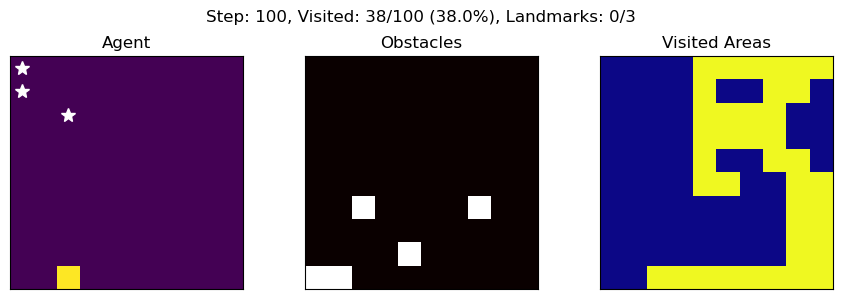


Test Episode 2:
------------------------------
  Step   0: Visited=  2, Explored=  2.0%, Landmarks=0
  Step  20: Visited= 12, Explored= 12.0%, Landmarks=1
  Step  40: Visited= 12, Explored= 12.0%, Landmarks=1
  Step  60: Visited= 12, Explored= 12.0%, Landmarks=1
  Step  80: Visited= 12, Explored= 12.0%, Landmarks=1

Episode Summary:
  Total Reward: 152.01
  Unique Cells Visited: 12
  Exploration Percentage: 12.0%
  Landmarks Discovered: 1/3
  Steps Taken: 100
  Success (>50% explored): No
  Action Distribution: {'Up': 5, 'Down': 88, 'Left': 2, 'Right': 5, 'Stay': 0}
  Exploration Efficiency: 0.120 (cells/step)

Final State Visualization:


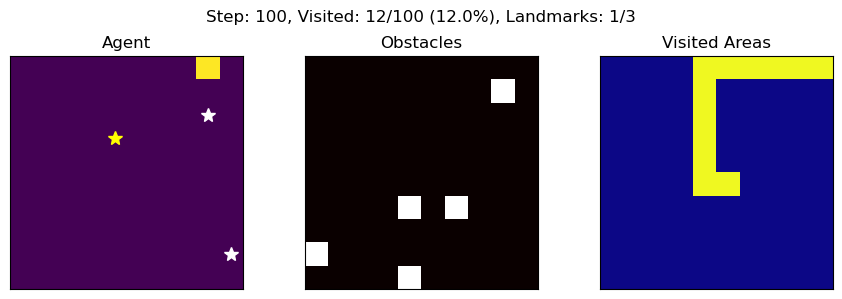


Test Episode 3:
------------------------------
  Step   0: Visited=  2, Explored=  2.0%, Landmarks=0
  Step  20: Visited= 21, Explored= 21.0%, Landmarks=1
  Step  40: Visited= 40, Explored= 40.0%, Landmarks=2
  Step  60: Visited= 49, Explored= 49.0%, Landmarks=2
  Step  80: Visited= 49, Explored= 49.0%, Landmarks=2

Episode Summary:
  Total Reward: 447.94
  Unique Cells Visited: 49
  Exploration Percentage: 49.0%
  Landmarks Discovered: 2/3
  Steps Taken: 100
  Success (>50% explored): No
  Action Distribution: {'Up': 23, 'Down': 23, 'Left': 29, 'Right': 25, 'Stay': 0}
  Exploration Efficiency: 0.490 (cells/step)

Final State Visualization:


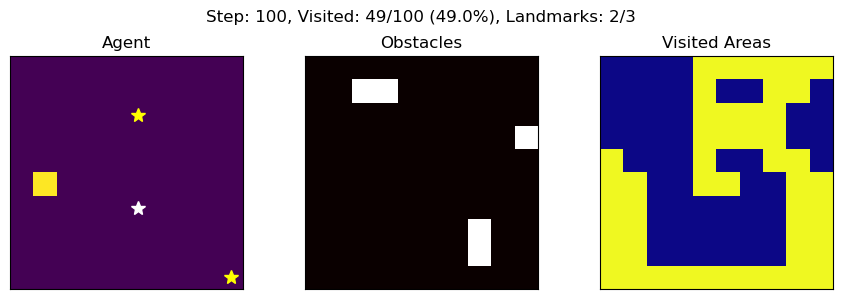


TEST SUMMARY
Average Reward: 330.94
Average Unique Cells: 33.0
Average Exploration %: 33.0%
Average Landmarks: 1.0
Success Rate: 0.0%
Average Steps: 100.0
Overall Exploration Efficiency: 0.330
Exploration model saved to exploration_agent_model.pkl


In [ ]:
# Import required libraries
import numpy as np
import random
from collections import defaultdict
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

# 1. Exploration-Focused Environment Class
class ExplorationEnv(gym.Env):
    """A 2D grid world optimized for exploration instinct."""
    
    def __init__(self, grid_size=10, num_obstacles=5, num_landmarks=3):
        super(ExplorationEnv, self).__init__()
        
        self.grid_size = grid_size
        self.num_obstacles = num_obstacles
        self.num_landmarks = num_landmarks
        
        # Action space: 0=up, 1=down, 2=left, 3=right, 4=stay
        self.action_space = spaces.Discrete(5)
        
        # Observation space: agent position + obstacles + unexplored areas
        self.observation_space = spaces.Box(
            low=0, high=1, 
            shape=(grid_size, grid_size, 3),  # 3 channels: agent, obstacles, visited
            dtype=np.float32
        )
        
        self.reset()
    
    def reset(self):
        """Reset the environment to initial state."""
        # Initialize empty grid
        self.grid = np.zeros((self.grid_size, self.grid_size, 3))
        
        # Place agent at center for fair exploration
        self.agent_pos = np.array([self.grid_size // 2, self.grid_size // 2])
        self.grid[self.agent_pos[0], self.agent_pos[1], 0] = 1
        
        # Place obstacles randomly (walls/blocked cells)
        self.obstacle_positions = []
        for _ in range(self.num_obstacles):
            pos = np.random.randint(0, self.grid_size, size=2)
            while np.array_equal(pos, self.agent_pos):
                pos = np.random.randint(0, self.grid_size, size=2)
            self.obstacle_positions.append(pos)
            self.grid[pos[0], pos[1], 1] = 1
        
        # Place exploration landmarks (special areas to discover)
        self.landmark_positions = []
        for _ in range(self.num_landmarks):
            pos = np.random.randint(0, self.grid_size, size=2)
            while (np.array_equal(pos, self.agent_pos) or 
                   any(np.array_equal(pos, o) for o in self.obstacle_positions)):
                pos = np.random.randint(0, self.grid_size, size=2)
            self.landmark_positions.append(pos)
        
        # Track visited areas
        self.visited = np.zeros((self.grid_size, self.grid_size))
        self.visited[self.agent_pos[0], self.agent_pos[1]] = 1
        self.grid[:, :, 2] = self.visited
        
        # Track discovered landmarks
        self.discovered_landmarks = set()
        
        # Statistics
        self.steps_taken = 0
        self.unique_cells_visited = 1
        self.landmarks_discovered = 0
        
        return self.grid.copy()
    
    def step(self, action):
        """Take a step in the environment."""
        old_pos = self.agent_pos.copy()
        
        # Update agent position based on action
        new_pos = self.agent_pos.copy()
        valid_move = True
        
        if action == 0 and self.agent_pos[0] > 0:  # up
            new_pos[0] -= 1
        elif action == 1 and self.agent_pos[0] < self.grid_size - 1:  # down
            new_pos[0] += 1
        elif action == 2 and self.agent_pos[1] > 0:  # left
            new_pos[1] -= 1
        elif action == 3 and self.agent_pos[1] < self.grid_size - 1:  # right
            new_pos[1] += 1
        elif action == 4:  # stay
            pass
        else:
            valid_move = False  # Hit boundary
        
        # Check for obstacles
        if valid_move and any(np.array_equal(new_pos, o) for o in self.obstacle_positions):
            valid_move = False  # Hit obstacle
        
        if valid_move:
            self.agent_pos = new_pos
        
        # Update grid
        self.grid[old_pos[0], old_pos[1], 0] = 0
        self.grid[self.agent_pos[0], self.agent_pos[1], 0] = 1
        
        # Update visited areas
        if not self.visited[self.agent_pos[0], self.agent_pos[1]]:
            self.visited[self.agent_pos[0], self.agent_pos[1]] = 1
            self.unique_cells_visited += 1
        
        # Check for landmark discovery
        for i, landmark_pos in enumerate(self.landmark_positions):
            if (np.array_equal(self.agent_pos, landmark_pos) and 
                i not in self.discovered_landmarks):
                self.discovered_landmarks.add(i)
                self.landmarks_discovered += 1
        
        self.grid[:, :, 2] = self.visited
        
        # Update statistics
        self.steps_taken += 1
        
        # Check if episode should end
        exploration_percentage = self.unique_cells_visited / (self.grid_size * self.grid_size)
        done = (self.steps_taken >= 100 or 
                exploration_percentage > 0.8 or  # Explored 80% of grid
                (self.steps_taken > 20 and self.unique_cells_visited == 1))  # Stuck
        
        # Base reward (minimal - exploration is its own reward)
        total_reward = 0.0
        
        return self.grid.copy(), total_reward, done, {
            'unique_cells': self.unique_cells_visited,
            'steps_taken': self.steps_taken,
            'landmarks_discovered': self.landmarks_discovered,
            'exploration_percentage': exploration_percentage,
            'stuck': 1 if self.steps_taken > 20 and self.unique_cells_visited == 1 else 0
        }
    
    def render(self, mode='human'):
        """Render the environment."""
        fig, axes = plt.subplots(1, 3, figsize=(9, 3))
        
        titles = ['Agent', 'Obstacles', 'Visited Areas']
        cmaps = ['viridis', 'hot', 'plasma']
        
        for i, ax in enumerate(axes):
            ax.imshow(self.grid[:, :, i], cmap=cmaps[i])
            ax.set_title(titles[i])
            ax.set_xticks([])
            ax.set_yticks([])
            
            # Mark landmarks with stars
            if i == 0:  # On agent view
                for landmark in self.landmark_positions:
                    if any(np.array_equal(landmark, o) for o in self.obstacle_positions):
                        continue
                    # Check if landmark has been discovered
                    is_discovered = False
                    for j, lm_pos in enumerate(self.landmark_positions):
                        if np.array_equal(landmark, lm_pos) and j in self.discovered_landmarks:
                            is_discovered = True
                            break
                    
                    color = 'yellow' if is_discovered else 'white'
                    ax.plot(landmark[1], landmark[0], '*', color=color, markersize=10)
        
        plt.suptitle(f'Step: {self.steps_taken}, Visited: {self.unique_cells_visited}/{self.grid_size*self.grid_size} '
                     f'({self.unique_cells_visited/(self.grid_size*self.grid_size)*100:.1f}%), '
                     f'Landmarks: {self.landmarks_discovered}/{self.num_landmarks}')
        plt.tight_layout()
        plt.show()

# 2. Pure Exploration Instinct Agent
class ExplorationInstinctAgent:
    """A Q-learning agent driven purely by exploration instinct."""
    
    def __init__(self, state_shape, num_actions, 
                 learning_rate=0.12, discount_factor=0.96, 
                 exploration_rate=1.0, exploration_decay=0.994):
        
        self.state_shape = state_shape
        self.num_actions = num_actions
        
        # Q-learning parameters
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate
        self.exploration_decay = exploration_decay
        self.min_exploration_rate = 0.1  # Keep higher exploration for discovering new areas
        
        # Initialize Q-table as dictionary for sparse states
        self.q_table = defaultdict(lambda: np.zeros(num_actions))
        
        # Statistics tracking
        self.training_history = []
        
        # For exploration tracking
        self.last_unique_cells = 0
        self.last_position = None
        self.position_history = []
    
    def state_to_key(self, state):
        """Relative local visited-cell pattern — avoids state space explosion."""
        agent_pos = np.argwhere(state[:, :, 0] == 1)[0]
        visited = state[:, :, 2]

        # 3x3 local visited pattern (relative offsets, skip agent cell)
        local = []
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                x, y = agent_pos[0] + dx, agent_pos[1] + dy
                if 0 <= x < state.shape[0] and 0 <= y < state.shape[1]:
                    local.append(str(int(visited[x, y])))
                else:
                    local.append('1')  # out-of-bounds treated as visited

        # Bin global exploration progress into 5 levels for broader context
        total_cells = state.shape[0] * state.shape[1]
        visited_count = int(np.sum(visited))
        explore_bin = min(int(visited_count / total_cells * 5), 4)

        return f"{''.join(local)}|e{explore_bin}"
    def choose_action(self, state):
        """Choose an action using epsilon-greedy policy with exploration bias."""
        state_key = self.state_to_key(state)
        
        # Exploration: try random actions
        if random.random() < self.exploration_rate:
            # Bias exploration away from staying still
            return random.randint(0, self.num_actions - 2)  # 0-3 only (no stay)
        
        # Exploitation: choose best action from Q-table
        return np.argmax(self.q_table[state_key])
    
    def compute_exploration_reward(self, env, action, info):
        """Compute reward specifically for exploration instinct."""
        reward = 0.0
        
        # 1. PRIMARY REWARD: Discovering new cells
        current_unique = info['unique_cells']
        
        # Immediate large reward when discovering a new cell
        if current_unique > self.last_unique_cells:
            discovery_bonus = 2.0  # Strong positive signal for exploration
            # Bonus for discovering multiple cells in quick succession
            if hasattr(self, 'consecutive_discoveries'):
                self.consecutive_discoveries += 1
                discovery_bonus += min(self.consecutive_discoveries * 0.5, 2.0)
            else:
                self.consecutive_discoveries = 1
                discovery_bonus += 0.5
            
            reward += discovery_bonus
        else:
            # Reset consecutive discoveries counter
            self.consecutive_discoveries = 0
        
        # Update last unique cells count
        self.last_unique_cells = current_unique
        
        # 2. REWARD: Moving to unvisited areas
        # Get current state information
        agent_channel = env.grid[:, :, 0]
        visited_channel = env.grid[:, :, 2]
        
        # Find agent position
        agent_pos = np.argwhere(agent_channel == 1)[0]
        
        # Calculate percentage of visited cells in local area (3x3)
        local_visited_count = 0
        local_total_cells = 0
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                x, y = agent_pos[0] + dx, agent_pos[1] + dy
                if 0 <= x < env.grid_size and 0 <= y < env.grid_size:
                    local_total_cells += 1
                    if visited_channel[x, y] == 1:
                        local_visited_count += 1
        
        local_novelty = 1.0 - (local_visited_count / local_total_cells) if local_total_cells > 0 else 0
        
        # Reward for being in novel (less visited) areas
        reward += local_novelty * 0.3
        
        # 3. REWARD: Discovering landmarks
        landmarks_discovered = info['landmarks_discovered']
        if hasattr(self, 'last_landmarks'):
            if landmarks_discovered > self.last_landmarks:
                reward += 3.0  # Large reward for landmark discovery
        self.last_landmarks = landmarks_discovered
        
        # 4. PENALTY: Staying in place
        if action == 4:  # Stay action
            reward -= 0.5  # Strong penalty for staying still
        
        # 5. PENALTY: Revisiting same area repeatedly
        if self.last_position is not None:
            # Convert agent_pos to tuple for comparison
            agent_pos_tuple = tuple(agent_pos)
            last_pos_tuple = tuple(self.last_position)
            
            if np.array_equal(agent_pos, self.last_position):
                reward -= 0.3  # Penalty for staying in same cell
            else:
                # Check if current position is in recent position history
                for pos_tuple in self.position_history[-5:]:
                    if np.array_equal(agent_pos, np.array(pos_tuple)):
                        reward -= 0.1
                        break
        
        # Update position history (keep last 10 positions)
        self.position_history.append(tuple(agent_pos))
        if len(self.position_history) > 10:
            self.position_history.pop(0)
        
        self.last_position = agent_pos.copy()
        
        # 6. REWARD: High exploration efficiency
        if info['steps_taken'] > 5:
            exploration_efficiency = info['unique_cells'] / info['steps_taken']
            if exploration_efficiency > 0.3:  # High efficiency
                reward += exploration_efficiency * 2.0
            elif exploration_efficiency < 0.1:  # Low efficiency
                reward -= 0.2
        
        # 7. REWARD: Overall exploration progress
        exploration_percentage = info['exploration_percentage']
        reward += exploration_percentage * 1.0  # Reward for exploring more of the grid
        
        # 8. PENALTY: Getting stuck (no new cells for many steps)
        if info.get('stuck', 0):
            reward -= 1.0
        
        # 9. REWARD: Frontier exploration (being near unexplored areas)
        # Count unvisited cells in Moore neighborhood (8 directions)
        frontier_cells = 0
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                x, y = agent_pos[0] + dx, agent_pos[1] + dy
                if (0 <= x < env.grid_size and 0 <= y < env.grid_size and 
                    visited_channel[x, y] == 0):
                    frontier_cells += 1
        
        reward += frontier_cells * 0.2
        
        return reward
        
    def learn(self, state, action, reward, next_state, done):
        """Update Q-values using standard Q-learning."""
        state_key = self.state_to_key(state)
        next_state_key = self.state_to_key(next_state)
        
        # Get current Q-value
        current_q = self.q_table[state_key][action]
        
        # Calculate target Q-value
        if done:
            target = reward
        else:
            target = reward + self.discount_factor * np.max(self.q_table[next_state_key])
        
        # Update Q-value
        self.q_table[state_key][action] = current_q + self.learning_rate * (target - current_q)
        
        # Decay exploration rate when episode ends
        if done:
            self.exploration_rate = max(
                self.min_exploration_rate,
                self.exploration_rate * self.exploration_decay
            )
    
    def train_episode(self, env, max_steps=100):
        """Train for one episode with exploration-focused learning."""
        state = env.reset()
        
        # Reset exploration tracking
        self.last_unique_cells = 0
        self.last_position = None
        self.position_history = []
        
        if hasattr(self, 'consecutive_discoveries'):
            self.consecutive_discoveries = 0
        if hasattr(self, 'last_landmarks'):
            self.last_landmarks = 0
        
        total_reward = 0
        steps = 0
        
        for step in range(max_steps):
            # Choose action based on current state
            action = self.choose_action(state)
            
            # Take action in environment
            next_state, base_reward, done, info = env.step(action)
            
            # Compute exploration-specific reward
            exploration_reward = self.compute_exploration_reward(env, action, info)
            
            # Learn from this experience
            self.learn(state, action, exploration_reward, next_state, done)
            
            # Update statistics
            total_reward += exploration_reward
            state = next_state
            steps = step + 1
            
            if done:
                break
        
        # Record training history for this episode
        self.training_history.append({
            'total_reward': total_reward,
            'steps': steps,
            'exploration_rate': self.exploration_rate,
            'unique_cells': info['unique_cells'],
            'landmarks_discovered': info['landmarks_discovered'],
            'exploration_percentage': info['exploration_percentage'],
            'stuck': info.get('stuck', 0),
            'success': 1 if info['exploration_percentage'] > 0.5 else 0  # Success = explored >50%
        })
        
        return total_reward, steps
    
    def get_performance_metrics(self, last_n_episodes=50):
        """Get performance metrics from recent training history."""
        if len(self.training_history) < last_n_episodes:
            last_n_episodes = len(self.training_history)
        
        recent_history = self.training_history[-last_n_episodes:]
        
        metrics = {
            'avg_reward': np.mean([h['total_reward'] for h in recent_history]),
            'avg_unique_cells': np.mean([h['unique_cells'] for h in recent_history]),
            'avg_exploration_percentage': np.mean([h['exploration_percentage'] for h in recent_history]) * 100,
            'success_rate': np.mean([h['success'] for h in recent_history]) * 100,
            'avg_landmarks': np.mean([h['landmarks_discovered'] for h in recent_history]),
            'avg_steps': np.mean([h['steps'] for h in recent_history]),
            'exploration_rate': recent_history[-1]['exploration_rate'] if recent_history else self.exploration_rate
        }
        
        return metrics
    
    def save_model(self, filename):
        """Save the trained Q-table to a file."""
        import pickle
        with open(filename, 'wb') as f:
            pickle.dump(dict(self.q_table), f)
        print(f"Exploration model saved to {filename}")
    
    def load_model(self, filename):
        """Load a trained Q-table from a file."""
        import pickle
        with open(filename, 'rb') as f:
            loaded_dict = pickle.load(f)
            self.q_table = defaultdict(lambda: np.zeros(self.num_actions), loaded_dict)
        print(f"Exploration model loaded from {filename}")

# 3. Training Function
def train_exploration_agent(num_episodes=500, show_progress=True):
    """Train the exploration instinct agent."""
    
    # Create environment
    env = ExplorationEnv(grid_size=10, num_obstacles=5, num_landmarks=3)
    
    # Create exploration agent
    agent = ExplorationInstinctAgent(
        state_shape=env.observation_space.shape,
        num_actions=env.action_space.n,
        learning_rate=0.12,
        discount_factor=0.96,
        exploration_rate=1.0,
        exploration_decay=0.994
    )
    
    print("=" * 60)
    print("TRAINING PURE EXPLORATION INSTINCT AGENT")
    print("=" * 60)
    print(f"Training for {num_episodes} episodes...")
    print(f"Grid: {env.grid_size}x{env.grid_size}, Obstacles: {env.num_obstacles}, Landmarks: {env.num_landmarks}")
    
    # Training statistics
    episode_rewards = []
    exploration_percentages = []
    
    # Training loop
    for episode in range(num_episodes):
        # Train one episode
        reward, steps = agent.train_episode(env)
        episode_rewards.append(reward)
        
        # Get exploration percentage from latest history entry
        if agent.training_history:
            exploration_percentages.append(agent.training_history[-1]['exploration_percentage'])
        
        # Show progress every 50 episodes
        if show_progress and (episode + 1) % 50 == 0:
            recent_rewards = episode_rewards[-50:]
            recent_exploration = exploration_percentages[-50:] if len(exploration_percentages) >= 50 else exploration_percentages
            
            avg_reward = np.mean(recent_rewards)
            avg_exploration = np.mean(recent_exploration) * 100 if recent_exploration else 0
            
            print(f"Episode {episode + 1}: "
                  f"Avg Reward = {avg_reward:.2f}, "
                  f"Avg Exploration = {avg_exploration:.1f}%, "
                  f"Exploration Rate = {agent.exploration_rate:.3f}")
    
    # Final performance report
    print("\n" + "=" * 60)
    print("TRAINING COMPLETE")
    print("=" * 60)
    
    metrics = agent.get_performance_metrics(50)
    
    print(f"\nFinal Performance (last 50 episodes):")
    print(f"  Average Reward: {metrics['avg_reward']:.2f}")
    print(f"  Average Unique Cells Visited: {metrics['avg_unique_cells']:.1f}")
    print(f"  Average Exploration Percentage: {metrics['avg_exploration_percentage']:.1f}%")
    print(f"  Success Rate (>50% explored): {metrics['success_rate']:.1f}%")
    print(f"  Average Landmarks Discovered: {metrics['avg_landmarks']:.2f}")
    print(f"  Average Steps per Episode: {metrics['avg_steps']:.1f}")
    print(f"  Final Exploration Rate: {metrics['exploration_rate']:.3f}")
    
    # Compare early vs late performance
    if len(agent.training_history) >= 100:
        early_metrics = {
            'reward': np.mean([h['total_reward'] for h in agent.training_history[:50]]),
            'exploration': np.mean([h['exploration_percentage'] for h in agent.training_history[:50]]) * 100,
            'unique_cells': np.mean([h['unique_cells'] for h in agent.training_history[:50]])
        }
        
        late_metrics = {
            'reward': np.mean([h['total_reward'] for h in agent.training_history[-50:]]),
            'exploration': np.mean([h['exploration_percentage'] for h in agent.training_history[-50:]]) * 100,
            'unique_cells': np.mean([h['unique_cells'] for h in agent.training_history[-50:]])
        }
        
        print(f"\nLearning Progress (early vs late):")
        print(f"  Reward: {early_metrics['reward']:.2f} → {late_metrics['reward']:.2f} "
              f"({(late_metrics['reward']-early_metrics['reward'])/abs(early_metrics['reward'])*100 if early_metrics['reward']!=0 else 0:+.1f}%)")
        print(f"  Exploration %: {early_metrics['exploration']:.1f}% → {late_metrics['exploration']:.1f}% "
              f"({late_metrics['exploration']-early_metrics['exploration']:+.1f}%)")
        print(f"  Unique Cells: {early_metrics['unique_cells']:.1f} → {late_metrics['unique_cells']:.1f} "
              f"({(late_metrics['unique_cells']-early_metrics['unique_cells'])/abs(early_metrics['unique_cells'])*100 if early_metrics['unique_cells']!=0 else 0:+.1f}%)")
    
    return agent, env, episode_rewards, exploration_percentages

# 4. Visualization Function
def visualize_exploration_learning(agent, episode_rewards, exploration_percentages):
    """Visualize the learning progress of the exploration agent."""
    
    if not agent.training_history:
        print("No training history available for visualization.")
        return
    
    plt.figure(figsize=(15, 12))
    
    # Plot 1: Reward over time
    plt.subplot(3, 2, 1)
    window_size = 20
    if len(episode_rewards) > window_size:
        smoothed_rewards = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
        plt.plot(smoothed_rewards, linewidth=2, color='purple')
        plt.xlabel('Episode')
        plt.ylabel('Smoothed Reward')
        plt.title('Exploration Agent: Learning Progress')
        plt.grid(True, alpha=0.3)
    else:
        plt.plot(episode_rewards, linewidth=2, color='purple')
        plt.xlabel('Episode')
        plt.ylabel('Reward')
        plt.title('Exploration Agent: Learning Progress')
        plt.grid(True, alpha=0.3)
    
    # Plot 2: Exploration percentage over time
    plt.subplot(3, 2, 2)
    if len(exploration_percentages) > window_size:
        smoothed_exploration = np.convolve(exploration_percentages, np.ones(window_size)/window_size, mode='valid')
        plt.plot(smoothed_exploration * 100, linewidth=2, color='orange')
    else:
        plt.plot([p * 100 for p in exploration_percentages], linewidth=2, color='orange')
    plt.xlabel('Episode')
    plt.ylabel('Exploration Percentage (%)')
    plt.title('Exploration Coverage Over Time')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    
    # Plot 3: Unique cells visited over time
    plt.subplot(3, 2, 3)
    unique_cells = [h['unique_cells'] for h in agent.training_history]
    if len(unique_cells) > window_size:
        smoothed_cells = np.convolve(unique_cells, np.ones(window_size)/window_size, mode='valid')
        plt.plot(smoothed_cells, linewidth=2, color='green')
    else:
        plt.plot(unique_cells, linewidth=2, color='green')
    plt.xlabel('Episode')
    plt.ylabel('Unique Cells Visited')
    plt.title('Unique Area Discovery')
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Exploration rate decay
    plt.subplot(3, 2, 4)
    exploration_rates = [h['exploration_rate'] for h in agent.training_history]
    plt.plot(exploration_rates, linewidth=2, color='red')
    plt.xlabel('Episode')
    plt.ylabel('Exploration Rate')
    plt.title('Exploration Rate Decay')
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Landmarks discovered over time
    plt.subplot(3, 2, 5)
    landmarks = [h['landmarks_discovered'] for h in agent.training_history]
    if len(landmarks) > window_size:
        smoothed_landmarks = np.convolve(landmarks, np.ones(window_size)/window_size, mode='valid')
        plt.plot(smoothed_landmarks, linewidth=2, color='blue')
    else:
        plt.plot(landmarks, linewidth=2, color='blue')
    plt.xlabel('Episode')
    plt.ylabel('Landmarks Discovered')
    plt.title('Landmark Discovery Over Time')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Steps per episode (efficiency)
    plt.subplot(3, 2, 6)
    steps = [h['steps'] for h in agent.training_history]
    if len(steps) > window_size:
        smoothed_steps = np.convolve(steps, np.ones(window_size)/window_size, mode='valid')
        plt.plot(smoothed_steps, linewidth=2, color='brown')
    else:
        plt.plot(steps, linewidth=2, color='brown')
    plt.xlabel('Episode')
    plt.ylabel('Steps per Episode')
    plt.title('Exploration Efficiency')
    plt.grid(True, alpha=0.3)
    
    plt.suptitle('Pure Exploration Instinct Agent Learning Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Print Q-table statistics
    print(f"\nQ-table Statistics:")
    print(f"  Number of states learned: {len(agent.q_table)}")
    if agent.q_table:
        sample_state = list(agent.q_table.keys())[0]
        print(f"  Sample state key: {sample_state}")
        print(f"  Q-values for sample state: {agent.q_table[sample_state]}")

# 5. Testing Function
def test_exploration_agent(agent, env=None, num_episodes=3, render=True):
    """Test the trained exploration agent."""
    
    if env is None:
        env = ExplorationEnv(grid_size=10, num_obstacles=5, num_landmarks=3)
    
    print("\n" + "=" * 60)
    print("TESTING PURE EXPLORATION INSTINCT AGENT")
    print("=" * 60)
    
    test_results = {
        'total_rewards': [],
        'unique_cells': [],
        'exploration_percentages': [],
        'landmarks_discovered': [],
        'steps': [],
        'success': []
    }
    
    for episode in range(num_episodes):
        state = env.reset()
        
        # Reset agent tracking
        agent.last_unique_cells = 0
        agent.last_position = None
        agent.position_history = []
        
        total_reward = 0
        done = False
        step = 0
        
        action_history = []
        
        print(f"\nTest Episode {episode + 1}:")
        print("-" * 30)
        
        while not done and step < 100:
            # Choose action (uses exploitation only during testing)
            original_exploration = agent.exploration_rate
            agent.exploration_rate = 0.0  # No exploration during testing
            action = agent.choose_action(state)
            agent.exploration_rate = original_exploration
            
            # Record action
            action_history.append(action)
            
            # Take action
            next_state, _, done, info = env.step(action)
            
            # Compute exploration reward
            exploration_reward = agent.compute_exploration_reward(env, action, info)
            total_reward += exploration_reward
            
            # Show progress
            if render and step % 20 == 0:
                print(f"  Step {step:3d}: Visited={info['unique_cells']:3d}, "
                      f"Explored={info['exploration_percentage']*100:5.1f}%, "
                      f"Landmarks={info['landmarks_discovered']}")
            
            state = next_state
            step += 1
        
        # Episode summary
        print(f"\nEpisode Summary:")
        print(f"  Total Reward: {total_reward:.2f}")
        print(f"  Unique Cells Visited: {info['unique_cells']}")
        print(f"  Exploration Percentage: {info['exploration_percentage']*100:.1f}%")
        print(f"  Landmarks Discovered: {info['landmarks_discovered']}/{env.num_landmarks}")
        print(f"  Steps Taken: {step}")
        print(f"  Success (>50% explored): {'Yes' if info['exploration_percentage'] > 0.5 else 'No'}")
        
        # Analyze action pattern
        action_names = ['Up', 'Down', 'Left', 'Right', 'Stay']
        action_counts = [action_history.count(i) for i in range(5)]
        print(f"  Action Distribution: {dict(zip(action_names, action_counts))}")
        
        # Calculate exploration efficiency
        if step > 0:
            efficiency = info['unique_cells'] / step
            print(f"  Exploration Efficiency: {efficiency:.3f} (cells/step)")
        
        # Store results
        test_results['total_rewards'].append(total_reward)
        test_results['unique_cells'].append(info['unique_cells'])
        test_results['exploration_percentages'].append(info['exploration_percentage'])
        test_results['landmarks_discovered'].append(info['landmarks_discovered'])
        test_results['steps'].append(step)
        test_results['success'].append(1 if info['exploration_percentage'] > 0.5 else 0)
        
        # Show final state
        if render:
            print("\nFinal State Visualization:")
            env.render()
    
    # Test summary
    print("\n" + "=" * 60)
    print("TEST SUMMARY")
    print("=" * 60)
    print(f"Average Reward: {np.mean(test_results['total_rewards']):.2f}")
    print(f"Average Unique Cells: {np.mean(test_results['unique_cells']):.1f}")
    print(f"Average Exploration %: {np.mean(test_results['exploration_percentages'])*100:.1f}%")
    print(f"Average Landmarks: {np.mean(test_results['landmarks_discovered']):.1f}")
    print(f"Success Rate: {np.mean(test_results['success']) * 100:.1f}%")
    print(f"Average Steps: {np.mean(test_results['steps']):.1f}")
    
    # Calculate exploration efficiency across all episodes
    total_cells = env.grid_size * env.grid_size
    total_possible_exploration = total_cells * num_episodes
    total_actual_exploration = sum(test_results['unique_cells'])
    overall_efficiency = total_actual_exploration / total_possible_exploration
    print(f"Overall Exploration Efficiency: {overall_efficiency:.3f}")
    
    return test_results

# 6. Main Execution (Example Usage)
if __name__ == "__main__":
    # Example 1: Train and test the exploration agent
    print("Example 1: Training Pure Exploration Instinct Agent")
    print("-" * 40)
    
    # Train the agent
    exploration_agent, env, rewards, exploration_percentages = train_exploration_agent(
        num_episodes=800, 
        show_progress=True
    )
    
    # Visualize learning
    visualize_exploration_learning(exploration_agent, rewards, exploration_percentages)
    
    # Test the trained agent
    test_results = test_exploration_agent(
        exploration_agent, 
        env, 
        num_episodes=3, 
        render=True
    )
    
    # Save the trained model
    exploration_agent.save_model("exploration_agent_model.pkl")

EXPLORATION AGENT TRAINING
Training Exploration Agent...
Grid: 8x8
Episodes: 300
----------------------------------------
Episode 50:
  Avg Reward: 40.41
  Avg Cells Visited: 20.8/64
  Explore Rate: 0.778

Episode 100:
  Avg Reward: 33.17
  Avg Cells Visited: 17.6/64
  Explore Rate: 0.606

Episode 150:
  Avg Reward: 33.57
  Avg Cells Visited: 17.8/64
  Explore Rate: 0.471



Episode 200:
  Avg Reward: 31.51
  Avg Cells Visited: 16.8/64
  Explore Rate: 0.367

Episode 250:
  Avg Reward: 31.92
  Avg Cells Visited: 16.9/64
  Explore Rate: 0.286

Episode 300:
  Avg Reward: 33.93
  Avg Cells Visited: 17.8/64
  Explore Rate: 0.222

TRAINING COMPLETE

Final Performance (last 50 episodes):
Average Reward: 33.93
Average Cells Visited: 17.8
Average % Explored: 27.8%


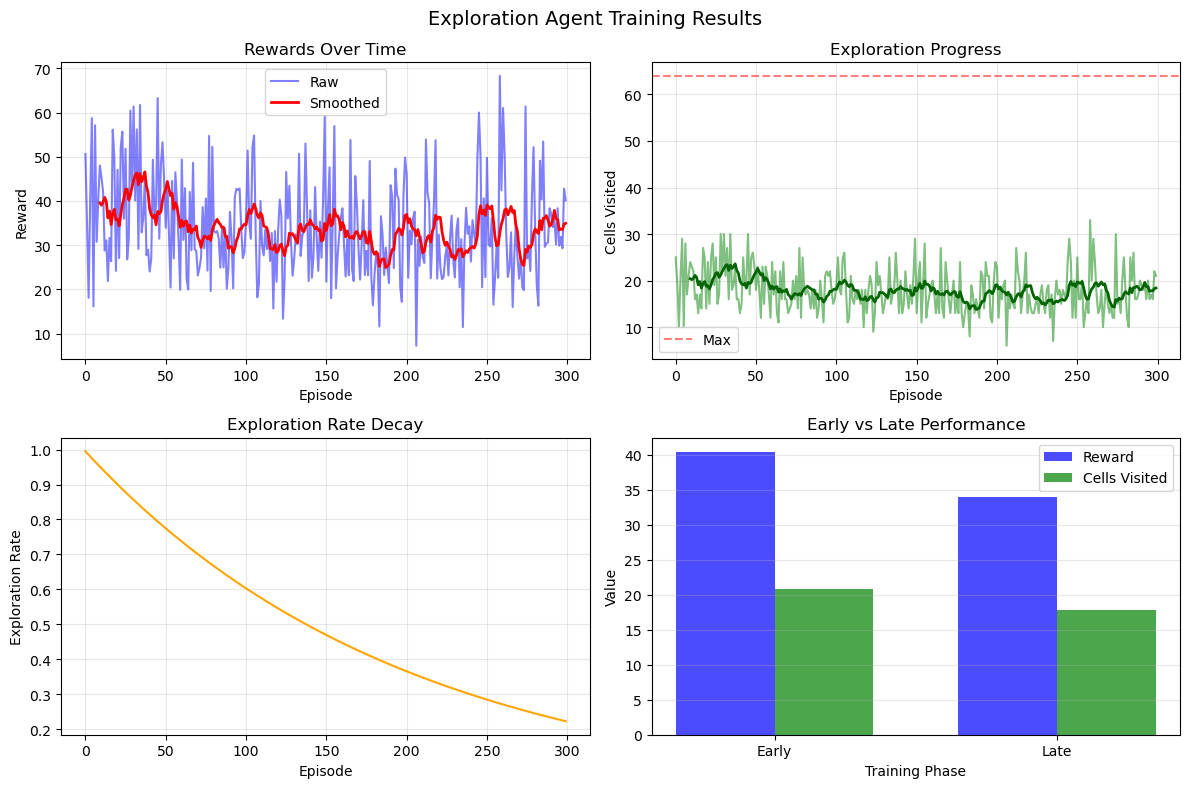


TESTING EXPLORATION AGENT

Episode 1:
  Reward: 21.15
  Steps: 50
  Cells Visited: 12/64
  % Explored: 18.8%

Episode 2:
  Reward: 32.52
  Steps: 50
  Cells Visited: 17/64
  % Explored: 26.6%

Episode 3:
  Reward: 30.30
  Steps: 50
  Cells Visited: 16/64
  % Explored: 25.0%

TEST SUMMARY
Average Reward: 27.99
Average Cells Visited: 15.0
Average % Explored: 23.4%

AGENT LEARNING SUMMARY
Cells visited improvement: -14.4%
Early: 20.8 cells
Late: 17.8 cells

Q-table size: 5276 states learned

Example learned state-action values:
State key: 2,1|0000000000001000000000000...
Action values: [0.02219141 0.0015625  0.         0.0015625 ]


In [ ]:
import numpy as np
import random
from collections import defaultdict
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

# 1. Simple Exploration Environment
class SimpleExplorationEnv(gym.Env):
    """Simple grid world for exploration training."""
    
    def __init__(self, grid_size=10):
        super(SimpleExplorationEnv, self).__init__()
        
        self.grid_size = grid_size
        
        # Action space: 0=up, 1=down, 2=left, 3=right
        self.action_space = spaces.Discrete(4)
        
        # Observation space: agent position + visited map
        self.observation_space = spaces.Box(
            low=0, high=1, 
            shape=(grid_size, grid_size, 2),  # 2 channels: agent, visited
            dtype=np.float32
        )
        
        self.reset()
    
    def reset(self):
        """Reset environment."""
        # Start with empty grid
        self.grid = np.zeros((self.grid_size, self.grid_size, 2))
        
        # Place agent at random position
        self.agent_pos = np.random.randint(0, self.grid_size, size=2)
        self.grid[self.agent_pos[0], self.agent_pos[1], 0] = 1
        
        # Track visited cells
        self.visited = np.zeros((self.grid_size, self.grid_size))
        self.visited[self.agent_pos[0], self.agent_pos[1]] = 1
        self.grid[:, :, 1] = self.visited
        
        # Statistics
        self.steps = 0
        self.visited_count = 1
        
        return self.grid.copy()
    
    def step(self, action):
        """Take a step."""
        old_pos = self.agent_pos.copy()
        
        # Move agent
        if action == 0 and self.agent_pos[0] > 0:  # up
            self.agent_pos[0] -= 1
        elif action == 1 and self.agent_pos[0] < self.grid_size - 1:  # down
            self.agent_pos[0] += 1
        elif action == 2 and self.agent_pos[1] > 0:  # left
            self.agent_pos[1] -= 1
        elif action == 3 and self.agent_pos[1] < self.grid_size - 1:  # right
            self.agent_pos[1] += 1
        
        # Update grid
        self.grid[old_pos[0], old_pos[1], 0] = 0
        self.grid[self.agent_pos[0], self.agent_pos[1], 0] = 1
        
        # Check if new cell
        if self.visited[self.agent_pos[0], self.agent_pos[1]] == 0:
            self.visited[self.agent_pos[0], self.agent_pos[1]] = 1
            self.visited_count += 1
        
        self.grid[:, :, 1] = self.visited
        self.steps += 1
        
        # Episode ends after 50 steps
        done = self.steps >= 50
        
        # Base reward is 0
        reward = 0.0
        
        return self.grid.copy(), reward, done, {
            'visited': self.visited_count,
            'steps': self.steps,
            'percent': self.visited_count / (self.grid_size * self.grid_size)
        }
    
    def render(self):
        """Show the grid."""
        plt.figure(figsize=(6, 3))
        
        plt.subplot(1, 2, 1)
        plt.imshow(self.grid[:, :, 0], cmap='Reds')
        plt.title('Agent')
        plt.xticks([])
        plt.yticks([])
        
        plt.subplot(1, 2, 2)
        plt.imshow(self.grid[:, :, 1], cmap='Blues')
        plt.title(f'Visited: {self.visited_count}')
        plt.xticks([])
        plt.yticks([])
        
        plt.suptitle(f'Step: {self.steps}')
        plt.tight_layout()
        plt.show()

# 2. Simple Exploration Agent
class SimpleExplorationAgent:
    """Simple Q-learning agent for exploration."""
    
    def __init__(self, state_shape, num_actions):
        self.state_shape = state_shape
        self.num_actions = num_actions
        
        # Learning parameters
        self.learning_rate = 0.1
        self.discount = 0.95
        self.explore_rate = 1.0
        self.explore_decay = 0.995
        self.min_explore = 0.01
        
        # Q-table (state -> action values)
        self.q_table = defaultdict(lambda: np.zeros(num_actions))
        
        # Training history
        self.history = []
    
    def get_state_key(self, state):
        """Convert state to simple string key."""
        # Find agent
        agent_layer = state[:, :, 0]
        agent_pos = np.argwhere(agent_layer == 1)[0]
        
        # Get visited cells in 5x5 area around agent
        visited_layer = state[:, :, 1]
        key_parts = []
        grid_size = state.shape[0]
        
        for dx in [-2, -1, 0, 1, 2]:
            for dy in [-2, -1, 0, 1, 2]:
                x = agent_pos[0] + dx
                y = agent_pos[1] + dy
                if 0 <= x < grid_size and 0 <= y < grid_size:
                    key_parts.append(str(int(visited_layer[x, y])))
                else:
                    key_parts.append('0')  # Out of bounds = not visited
        
        # Key: agent_position + local_visited_pattern
        key = f"{agent_pos[0]},{agent_pos[1]}|{''.join(key_parts)}"
        return key
    
    def choose_action(self, state):
        """Choose action: explore or exploit."""
        state_key = self.get_state_key(state)
        
        # Random exploration
        if random.random() < self.explore_rate:
            return random.randint(0, self.num_actions - 1)
        
        # Choose best action
        return np.argmax(self.q_table[state_key])
    
    def get_reward(self, env, action, info):
        """Calculate exploration reward."""
        reward = 0.0
        
        # Check if we visited a new cell
        current_visited = info['visited']
        if not hasattr(self, 'last_visited'):
            self.last_visited = current_visited
        
        # Big reward for finding new cell
        if current_visited > self.last_visited:
            reward += 2.0
        
        self.last_visited = current_visited
        
        # Small penalty for staying in visited areas too much
        visited_percent = info['percent']
        if visited_percent < 0.3 and info['steps'] > 20:
            reward -= 0.1  # Not exploring enough
        
        # Reward for high percentage explored
        reward += visited_percent * 0.5
        
        return reward
    
    def learn(self, state, action, reward, next_state, done):
        """Update Q-values."""
        state_key = self.get_state_key(state)
        next_key = self.get_state_key(next_state)
        
        current_q = self.q_table[state_key][action]
        
        if done:
            target = reward
        else:
            target = reward + self.discount * np.max(self.q_table[next_key])
        
        # Q-learning update
        new_q = current_q + self.learning_rate * (target - current_q)
        self.q_table[state_key][action] = new_q
        
        # Reduce exploration rate
        if done:
            self.explore_rate = max(self.min_explore, self.explore_rate * self.explore_decay)
    
    def train_episode(self, env):
        """Train for one episode."""
        state = env.reset()
        total_reward = 0
        steps = 0
        
        # Reset tracking
        if hasattr(self, 'last_visited'):
            del self.last_visited
        
        while True:
            # Choose and take action
            action = self.choose_action(state)
            next_state, _, done, info = env.step(action)
            
            # Get reward
            reward = self.get_reward(env, action, info)
            
            # Learn
            self.learn(state, action, reward, next_state, done)
            
            # Update
            total_reward += reward
            state = next_state
            steps += 1
            
            if done:
                break
        
        # Save results
        self.history.append({
            'reward': total_reward,
            'steps': steps,
            'visited': info['visited'],
            'percent': info['percent'],
            'explore_rate': self.explore_rate
        })
        
        return total_reward, steps

# 3. Training Function
def train_explorer(episodes=500):
    """Train exploration agent."""
    
    # Setup
    env = SimpleExplorationEnv(grid_size=8)  # Smaller grid for faster learning
    agent = SimpleExplorationAgent(
        state_shape=env.observation_space.shape,
        num_actions=env.action_space.n
    )
    
    print("Training Exploration Agent...")
    print(f"Grid: {env.grid_size}x{env.grid_size}")
    print(f"Episodes: {episodes}")
    print("-" * 40)
    
    rewards = []
    visited_counts = []
    
    for episode in range(episodes):
        # Train
        reward, steps = agent.train_episode(env)
        rewards.append(reward)
        visited_counts.append(agent.history[-1]['visited'])
        
        # Show progress
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(rewards[-50:])
            avg_visited = np.mean(visited_counts[-50:])
            max_possible = env.grid_size * env.grid_size
            
            print(f"Episode {episode + 1}:")
            print(f"  Avg Reward: {avg_reward:.2f}")
            print(f"  Avg Cells Visited: {avg_visited:.1f}/{max_possible}")
            print(f"  Explore Rate: {agent.explore_rate:.3f}")
            print()
    
    # Final results
    print("=" * 40)
    print("TRAINING COMPLETE")
    print("=" * 40)
    
    # Last 50 episodes performance
    last_50 = agent.history[-50:] if len(agent.history) >= 50 else agent.history
    
    if last_50:
        avg_last_reward = np.mean([h['reward'] for h in last_50])
        avg_last_visited = np.mean([h['visited'] for h in last_50])
        avg_last_percent = np.mean([h['percent'] for h in last_50])
        
        print(f"\nFinal Performance (last {len(last_50)} episodes):")
        print(f"Average Reward: {avg_last_reward:.2f}")
        print(f"Average Cells Visited: {avg_last_visited:.1f}")
        print(f"Average % Explored: {avg_last_percent*100:.1f}%")
    
    return agent, env, rewards, visited_counts

# 4. Visualization
def plot_results(agent, rewards, visited_counts):
    """Plot training results."""
    
    if not agent.history:
        print("No training data to plot.")
        return
    
    plt.figure(figsize=(12, 8))
    
    # Plot 1: Rewards over time
    plt.subplot(2, 2, 1)
    plt.plot(rewards, alpha=0.5, color='blue', label='Raw')
    
    # Smoothed line
    if len(rewards) > 10:
        window = 10
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(rewards)), smoothed, color='red', 
                linewidth=2, label='Smoothed')
    
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('Rewards Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Cells visited over time
    plt.subplot(2, 2, 2)
    max_cells = 64  # For 8x8 grid
    plt.plot(visited_counts, alpha=0.5, color='green')
    
    if len(visited_counts) > 10:
        window = 10
        smoothed_visits = np.convolve(visited_counts, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(visited_counts)), smoothed_visits, 
                color='darkgreen', linewidth=2)
    
    plt.axhline(y=max_cells, color='red', linestyle='--', alpha=0.5, label='Max')
    plt.xlabel('Episode')
    plt.ylabel('Cells Visited')
    plt.title('Exploration Progress')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Exploration rate decay
    plt.subplot(2, 2, 3)
    explore_rates = [h['explore_rate'] for h in agent.history]
    plt.plot(explore_rates, color='orange')
    plt.xlabel('Episode')
    plt.ylabel('Exploration Rate')
    plt.title('Exploration Rate Decay')
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Performance comparison (early vs late)
    plt.subplot(2, 2, 4)
    
    if len(agent.history) >= 100:
        early = agent.history[:50]
        late = agent.history[-50:]
        
        early_reward = np.mean([h['reward'] for h in early])
        late_reward = np.mean([h['reward'] for h in late])
        
        early_visited = np.mean([h['visited'] for h in early])
        late_visited = np.mean([h['visited'] for h in late])
        
        categories = ['Early', 'Late']
        reward_values = [early_reward, late_reward]
        visited_values = [early_visited, late_visited]
        
        x = np.arange(len(categories))
        width = 0.35
        
        plt.bar(x - width/2, reward_values, width, label='Reward', color='blue', alpha=0.7)
        plt.bar(x + width/2, visited_values, width, label='Cells Visited', color='green', alpha=0.7)
        
        plt.xlabel('Training Phase')
        plt.ylabel('Value')
        plt.title('Early vs Late Performance')
        plt.xticks(x, categories)
        plt.legend()
        plt.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Exploration Agent Training Results', fontsize=14)
    plt.tight_layout()
    plt.show()

# 5. Test Function
def test_explorer(agent, env=None, episodes=3):
    """Test trained agent."""
    
    if env is None:
        env = SimpleExplorationEnv(grid_size=8)
    
    print("\n" + "=" * 40)
    print("TESTING EXPLORATION AGENT")
    print("=" * 40)
    
    results = []
    
    for ep in range(episodes):
        state = env.reset()
        done = False
        ep_reward = 0
        ep_steps = 0
        
        # Save original explore rate
        old_explore = agent.explore_rate
        
        # Set explore to 0 for testing (pure exploitation)
        agent.explore_rate = 0.0
        
        # Reset tracking
        if hasattr(agent, 'last_visited'):
            del agent.last_visited
        
        while not done:
            action = agent.choose_action(state)
            next_state, _, done, info = env.step(action)
            
            # Get reward (for tracking)
            reward = agent.get_reward(env, action, info)
            ep_reward += reward
            
            state = next_state
            ep_steps += 1
        
        # Restore explore rate
        agent.explore_rate = old_explore
        
        # Save results
        results.append({
            'reward': ep_reward,
            'steps': ep_steps,
            'visited': info['visited'],
            'percent': info['percent']
        })
        
        print(f"\nEpisode {ep + 1}:")
        print(f"  Reward: {ep_reward:.2f}")
        print(f"  Steps: {ep_steps}")
        print(f"  Cells Visited: {info['visited']}/{env.grid_size*env.grid_size}")
        print(f"  % Explored: {info['percent']*100:.1f}%")
    
    # Summary
    print("\n" + "=" * 40)
    print("TEST SUMMARY")
    print("=" * 40)
    
    avg_reward = np.mean([r['reward'] for r in results])
    avg_visited = np.mean([r['visited'] for r in results])
    avg_percent = np.mean([r['percent'] for r in results])
    
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Average Cells Visited: {avg_visited:.1f}")
    print(f"Average % Explored: {avg_percent*100:.1f}%")
    
    return results

# 6. Main Program
def main():
    """Run the exploration agent."""
    
    # Train
    print("EXPLORATION AGENT TRAINING")
    print("=" * 50)
    
    agent, env, rewards, visited_counts = train_explorer(episodes=300)
    
    # Plot results
    plot_results(agent, rewards, visited_counts)
    
    # Test
    test_results = test_explorer(agent, env, episodes=3)
    
    # Show what the agent learned
    print("\n" + "=" * 50)
    print("AGENT LEARNING SUMMARY")
    print("=" * 50)
    
    # Check improvement
    if len(agent.history) >= 100:
        early_history = agent.history[:50]
        late_history = agent.history[-50:]
        
        early_avg_visited = np.mean([h['visited'] for h in early_history])
        late_avg_visited = np.mean([h['visited'] for h in late_history])
        
        improvement = ((late_avg_visited - early_avg_visited) / early_avg_visited) * 100
        
        print(f"Cells visited improvement: {improvement:+.1f}%")
        print(f"Early: {early_avg_visited:.1f} cells")
        print(f"Late: {late_avg_visited:.1f} cells")
    
    # Show Q-table size
    print(f"\nQ-table size: {len(agent.q_table)} states learned")
    
    # Example of learned behavior
    print("\nExample learned state-action values:")
    if agent.q_table:
        sample_state = list(agent.q_table.keys())[0]
        print(f"State key: {sample_state[:50]}...")
        print(f"Action values: {agent.q_table[sample_state]}")

# Run if this file is executed
if __name__ == "__main__":
    main()

TRAINING SURVIVAL INSTINCT AGENT
Training for 2000 episodes...
Grid: 8x8, Dangers: 4, Safe Zones: 2
Episode 50: Avg Reward = 6.07, Avg Steps Survived = 14.8, Exploration = 0.778
Episode 100: Avg Reward = 9.27, Avg Steps Survived = 16.4, Exploration = 0.606
Episode 150: Avg Reward = 15.65, Avg Steps Survived = 18.5, Exploration = 0.471


Episode 200: Avg Reward = 10.96, Avg Steps Survived = 17.0, Exploration = 0.367
Episode 250: Avg Reward = 10.30, Avg Steps Survived = 16.4, Exploration = 0.286


Episode 300: Avg Reward = 10.20, Avg Steps Survived = 15.8, Exploration = 0.222
Episode 350: Avg Reward = 16.43, Avg Steps Survived = 18.1, Exploration = 0.173
Episode 400: Avg Reward = 11.45, Avg Steps Survived = 16.9, Exploration = 0.135
Episode 450: Avg Reward = 21.38, Avg Steps Survived = 20.0, Exploration = 0.105


Episode 500: Avg Reward = 17.51, Avg Steps Survived = 18.8, Exploration = 0.082


Episode 550: Avg Reward = 24.93, Avg Steps Survived = 20.7, Exploration = 0.063
Episode 600: Avg Reward = 33.44, Avg Steps Survived = 22.1, Exploration = 0.050
Episode 650: Avg Reward = 29.99, Avg Steps Survived = 21.0, Exploration = 0.050


...

Episode 1250: Avg Reward = 16.08, Avg Steps Survived = 19.3, Exploration = 0.050
Episode 1300: Avg Reward = 21.53, Avg Steps Survived = 20.3, Exploration = 0.050
Episode 1350: Avg Reward = 18.95, Avg Steps Survived = 19.6, Exploration = 0.050
Episode 1400: Avg Reward = 19.13, Avg Steps Survived = 19.9, Exploration = 0.050
Episode 1450: Avg Reward = 22.48, Avg Steps Survived = 20.4, Exploration = 0.050


Episode 1500: Avg Reward = 46.46, Avg Steps Survived = 26.2, Exploration = 0.050
Episode 1550: Avg Reward = 14.73, Avg Steps Survived = 19.1, Exploration = 0.050
Episode 1600: Avg Reward = 24.46, Avg Steps Survived = 21.7, Exploration = 0.050


Episode 1650: Avg Reward = 16.84, Avg Steps Survived = 18.9, Exploration = 0.050
Episode 1700: Avg Reward = 25.28, Avg Steps Survived = 21.6, Exploration = 0.050
Episode 1750: Avg Reward = 38.60, Avg Steps Survived = 22.6, Exploration = 0.050


Episode 1800: Avg Reward = 24.53, Avg Steps Survived = 22.1, Exploration = 0.050
Episode 1850: Avg Reward = 19.34, Avg Steps Survived = 19.6, Exploration = 0.050
Episode 1900: Avg Reward = 21.56, Avg Steps Survived = 21.5, Exploration = 0.050


Episode 1950: Avg Reward = 26.16, Avg Steps Survived = 22.3, Exploration = 0.050
Episode 2000: Avg Reward = 26.80, Avg Steps Survived = 22.7, Exploration = 0.050

TRAINING COMPLETE

Final Performance (last 50 episodes):
  Average Reward: 26.80
  Average Steps Survived: 22.7
  Success Rate (survived >=30 steps without danger): 10.0%
  Average Safe Zones Visited: 3.30
  Danger Hit Rate: 16.0%
  Final Exploration Rate: 0.050

Learning Progress (early vs late):
  Reward: 6.07 -> 26.80 (+341.4%)
  Steps Survived: 14.8 -> 22.7 (+7.9)
  Success Rate: 0.0% -> 10.0% (+10.0%)


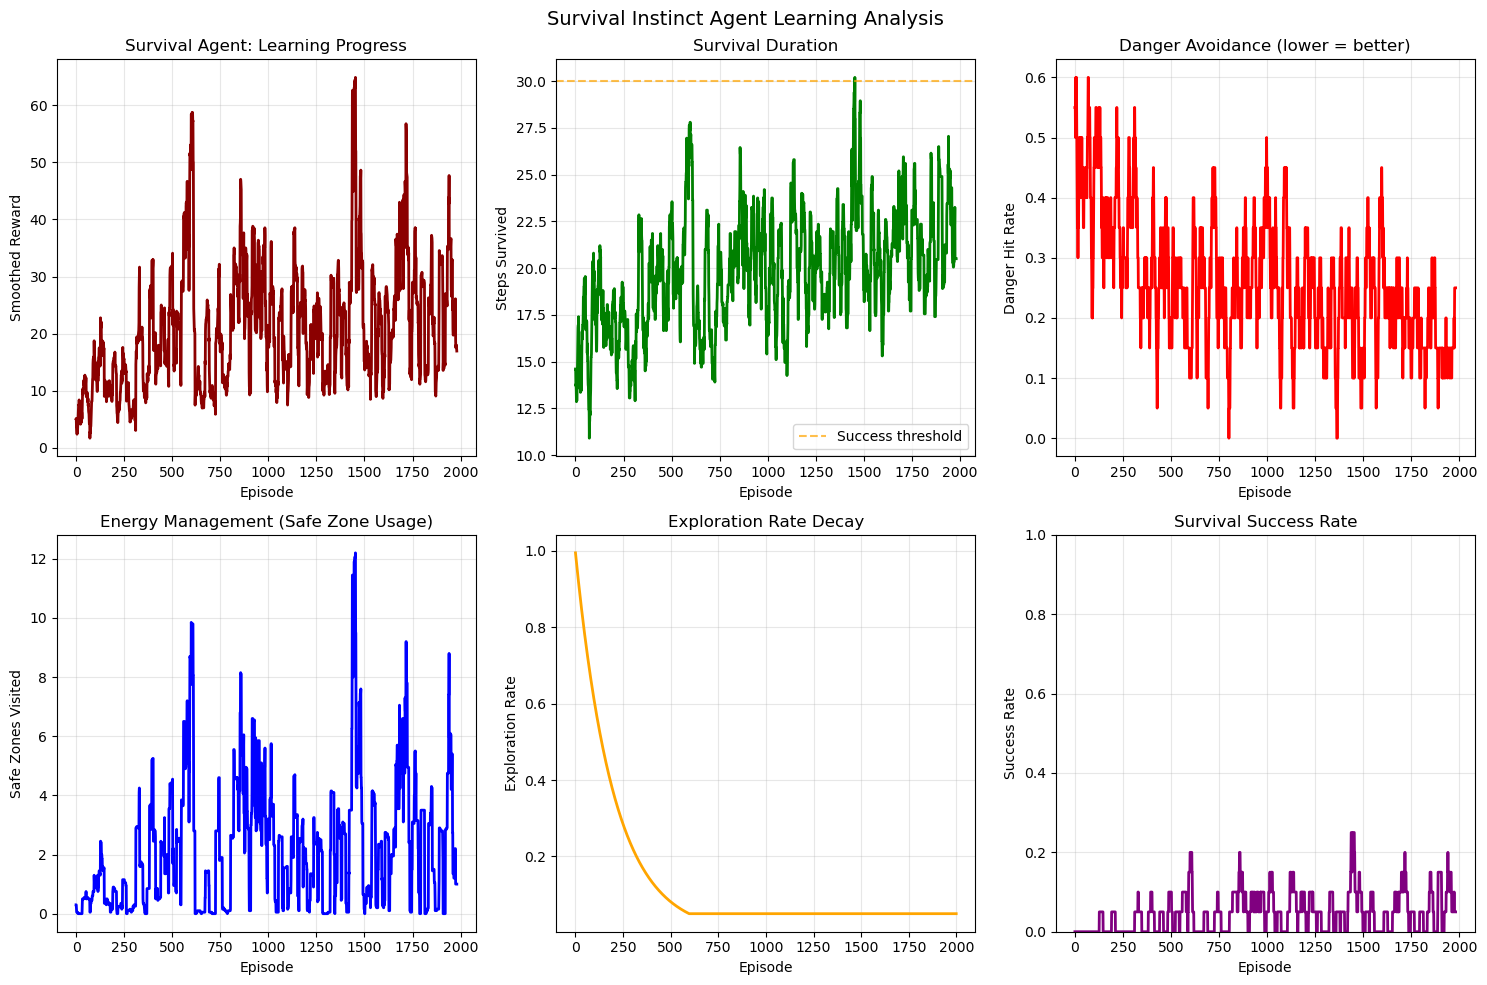


Q-table Statistics:
  Number of states learned: 7766
  Sample state key: (1,1,3),(1,-1,3)|(1,1,3)|e4
  Q-values for sample state: [0.        0.12      0.        3.1628177 0.       ]

TESTING SURVIVAL INSTINCT AGENT

Test Episode 1:
------------------------------
  Step  0: Energy=0.95, Reward=1.20, Safe Zones=0
  Step 10: Energy=0.45, Reward=1.20, Safe Zones=0

Episode Summary:
  Total Reward: 16.70
  Steps Survived: 20
  Final Energy: 0.00
  Safe Zones Visited: 0
  Hit Danger: No
  Success: No
  Action Distribution: {'Up': 10, 'Down': 1, 'Left': 5, 'Right': 4, 'Stay': 0}

Final State:


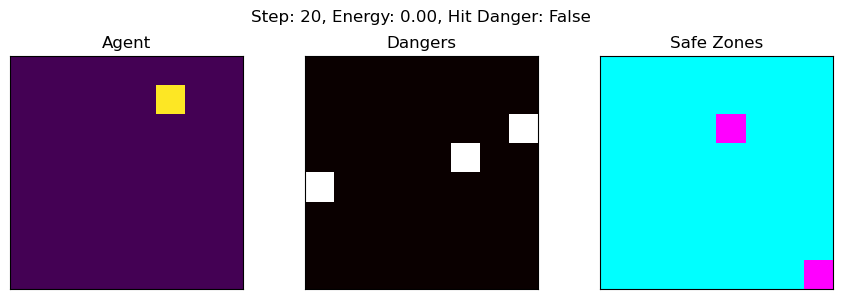


Test Episode 2:
------------------------------
  Step  0: Energy=0.95, Reward=1.40, Safe Zones=0
  Step 10: Energy=0.95, Reward=1.40, Safe Zones=2
  Step 20: Energy=0.95, Reward=1.40, Safe Zones=4
  Step 30: Energy=0.95, Reward=1.70, Safe Zones=6
  Step 40: Energy=0.95, Reward=1.70, Safe Zones=8
  Step 50: Energy=0.95, Reward=2.20, Safe Zones=10

Episode Summary:
  Total Reward: 126.80
  Steps Survived: 60
  Final Energy: 1.00
  Safe Zones Visited: 12
  Hit Danger: No
  Success: Yes
  Action Distribution: {'Up': 48, 'Down': 12, 'Left': 0, 'Right': 0, 'Stay': 0}

Final State:


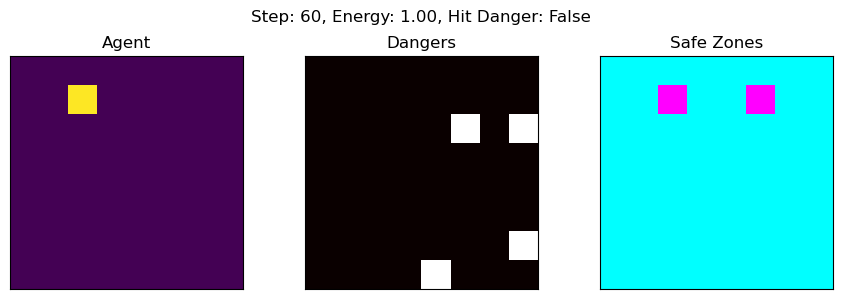


Test Episode 3:
------------------------------
  Step  0: Energy=0.95, Reward=-0.00, Safe Zones=0

Episode Summary:
  Total Reward: -9.50
  Steps Survived: 2
  Final Energy: 0.90
  Safe Zones Visited: 0
  Hit Danger: Yes
  Success: No
  Action Distribution: {'Up': 2, 'Down': 0, 'Left': 0, 'Right': 0, 'Stay': 0}

Final State:


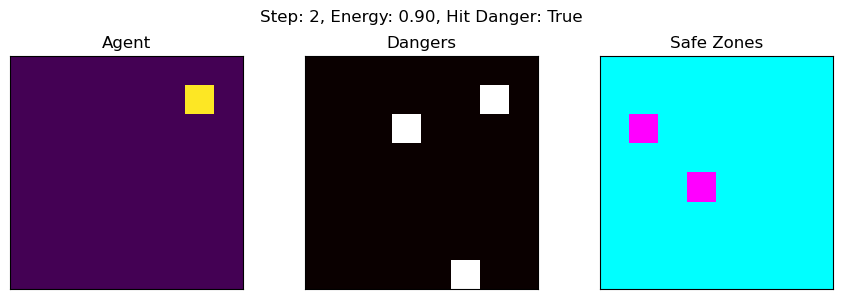


TEST SUMMARY
Average Reward: 44.67
Average Steps Survived: 27.3
Average Safe Zones Visited: 4.00
Danger Hit Rate: 33.3%
Success Rate: 33.3%
Survival model saved to survival_agent_model.pkl


In [ ]:
import numpy as np
import random
from collections import defaultdict
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

# 1. Survival Environment
class SurvivalEnv(gym.Env):
    """A 2D grid world focused on survival - avoiding dangers and managing energy."""

    def __init__(self, grid_size=8, num_dangers=4, num_safe_zones=2):
        super(SurvivalEnv, self).__init__()

        self.grid_size = grid_size
        self.num_dangers = num_dangers
        self.num_safe_zones = num_safe_zones

        # Action space: 0=up, 1=down, 2=left, 3=right, 4=stay
        self.action_space = spaces.Discrete(5)

        # Observation space: agent, dangers, safe zones
        self.observation_space = spaces.Box(
            low=0, high=1,
            shape=(grid_size, grid_size, 3),
            dtype=np.float32
        )

        self.reset()

    def reset(self):
        self.grid = np.zeros((self.grid_size, self.grid_size, 3))

        self.agent_pos = np.random.randint(0, self.grid_size, size=2)
        self.grid[self.agent_pos[0], self.agent_pos[1], 0] = 1

        # Place dangers
        self.danger_positions = []
        for _ in range(self.num_dangers):
            pos = np.random.randint(0, self.grid_size, size=2)
            while np.array_equal(pos, self.agent_pos):
                pos = np.random.randint(0, self.grid_size, size=2)
            self.danger_positions.append(pos)
            self.grid[pos[0], pos[1], 1] = 1

        # Place safe zones (energy replenishment spots)
        self.safe_zone_positions = []
        for _ in range(self.num_safe_zones):
            pos = np.random.randint(0, self.grid_size, size=2)
            while (np.array_equal(pos, self.agent_pos) or
                   any(np.array_equal(pos, d) for d in self.danger_positions)):
                pos = np.random.randint(0, self.grid_size, size=2)
            self.safe_zone_positions.append(pos)
            self.grid[pos[0], pos[1], 2] = 1

        # Energy system
        self.energy = 1.0
        self.energy_decay = 0.05
        self.energy_gain = 0.3

        # Statistics
        self.steps_survived = 0
        self.dangers_hit = 0
        self.safe_zones_visited = 0
        self.hit_danger = False

        return self.grid.copy()

    def step(self, action):
        old_pos = self.agent_pos.copy()

        if action == 0 and self.agent_pos[0] > 0:
            self.agent_pos[0] -= 1
        elif action == 1 and self.agent_pos[0] < self.grid_size - 1:
            self.agent_pos[0] += 1
        elif action == 2 and self.agent_pos[1] > 0:
            self.agent_pos[1] -= 1
        elif action == 3 and self.agent_pos[1] < self.grid_size - 1:
            self.agent_pos[1] += 1
        # action == 4: stay

        self.grid[old_pos[0], old_pos[1], 0] = 0
        self.grid[self.agent_pos[0], self.agent_pos[1], 0] = 1

        # Deplete energy each step
        self.energy = max(0.0, self.energy - self.energy_decay)

        # Check safe zone
        at_safe_zone = False
        for sz_pos in self.safe_zone_positions:
            if np.array_equal(self.agent_pos, sz_pos):
                self.energy = min(1.0, self.energy + self.energy_gain)
                self.safe_zones_visited += 1
                at_safe_zone = True
                break

        # Check danger
        self.hit_danger = False
        for d_pos in self.danger_positions:
            if np.array_equal(self.agent_pos, d_pos):
                self.hit_danger = True
                self.dangers_hit += 1
                break

        self.steps_survived += 1
        done = self.hit_danger or self.energy <= 0 or self.steps_survived >= 60

        return self.grid.copy(), 0.0, done, {
            'steps_survived': self.steps_survived,
            'energy': self.energy,
            'hit_danger': self.hit_danger,
            'at_safe_zone': at_safe_zone,
            'safe_zones_visited': self.safe_zones_visited,
            'dangers_hit': self.dangers_hit
        }

    def render(self, mode='human'):
        fig, axes = plt.subplots(1, 3, figsize=(9, 3))
        titles = ['Agent', 'Dangers', 'Safe Zones']
        cmaps = ['viridis', 'hot', 'cool']
        for i, ax in enumerate(axes):
            ax.imshow(self.grid[:, :, i], cmap=cmaps[i])
            ax.set_title(titles[i])
            ax.set_xticks([])
            ax.set_yticks([])
        plt.suptitle(f'Step: {self.steps_survived}, Energy: {self.energy:.2f}, '
                     f'Hit Danger: {self.hit_danger}')
        plt.tight_layout()
        plt.show()


# 2. Survival Instinct Agent
class SurvivalInstinctAgent:
    """A Q-learning agent driven purely by survival instinct."""

    def __init__(self, state_shape, num_actions,
                 learning_rate=0.15, discount_factor=0.97,
                 exploration_rate=1.0, exploration_decay=0.995):

        self.state_shape = state_shape
        self.num_actions = num_actions
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate
        self.exploration_decay = exploration_decay
        self.min_exploration_rate = 0.05

        self.q_table = defaultdict(lambda: np.zeros(num_actions))
        self.training_history = []

    def state_to_key(self, state, energy):
        """Relative direction+distance encoding — avoids state space explosion."""
        agent_pos = np.argwhere(state[:, :, 0] == 1)[0]
        danger_pos = np.argwhere(state[:, :, 1] == 1)
        safe_pos = np.argwhere(state[:, :, 2] == 1)

        def rel_key(target, src_pos):
            dr = int(target[0]) - int(src_pos[0])
            dc = int(target[1]) - int(src_pos[1])
            dist = abs(dr) + abs(dc)
            rd = 0 if dr == 0 else (1 if dr > 0 else -1)
            cd = 0 if dc == 0 else (1 if dc > 0 else -1)
            db = 1 if dist <= 1 else (2 if dist <= 3 else 3)
            return f"({rd},{cd},{db})"

        # Nearest danger direction+distance
        if len(danger_pos) > 0:
            dists = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in danger_pos]
            nearest_idx = np.argmin(dists)
            danger_key = rel_key(danger_pos[nearest_idx], agent_pos)
            # Second nearest (there are 4 dangers, so this is meaningful)
            if len(danger_pos) > 1:
                dists2 = dists.copy()
                dists2[nearest_idx] = 999
                danger_key += "," + rel_key(danger_pos[np.argmin(dists2)], agent_pos)
        else:
            danger_key = "dnone"

        # Nearest safe zone direction+distance
        if len(safe_pos) > 0:
            dists = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in safe_pos]
            safe_key = rel_key(safe_pos[np.argmin(dists)], agent_pos)
        else:
            safe_key = "snone"

        # Energy discretised into 5 bands
        e_band = min(int(energy * 5), 4)

        return f"{danger_key}|{safe_key}|e{e_band}"
    def choose_action(self, state, energy):
        """Choose action using epsilon-greedy policy."""
        state_key = self.state_to_key(state, energy)

        if random.random() < self.exploration_rate:
            return random.randint(0, self.num_actions - 2)  # no stay during exploration

        return np.argmax(self.q_table[state_key])

    def compute_survival_reward(self, env, action, info):
        """Compute reward specifically for survival instinct."""
        reward = 0.0

        # 1. SURVIVAL REWARD: reward for each step alive
        reward += 0.5

        # 2. ENERGY MANAGEMENT
        energy = info['energy']
        if energy > 0.6:
            reward += 0.2
        elif energy < 0.3:
            reward -= 0.3
        if energy <= 0.0:
            reward -= 2.0

        # 3. SAFE ZONE REWARD
        if info['at_safe_zone']:
            reward += 3.0

        # 4. DANGER PENALTY
        if info['hit_danger']:
            reward -= 10.0

        # 5. AVOIDANCE REWARD: reward based on distance from nearest danger
        agent_channel = env.grid[:, :, 0]
        danger_channel = env.grid[:, :, 1]
        agent_pos = np.argwhere(agent_channel == 1)[0]
        danger_positions = np.argwhere(danger_channel == 1)

        if len(danger_positions) > 0:
            distances = [abs(pos[0]-agent_pos[0]) + abs(pos[1]-agent_pos[1])
                        for pos in danger_positions]
            min_dist = min(distances)

            if min_dist >= 3:
                reward += 0.3
            elif min_dist == 2:
                reward += 0.1
            elif min_dist == 1:
                reward -= 0.5

            # Reconstruct old position to evaluate movement direction
            old_pos = agent_pos.copy()
            if action == 0: old_pos[0] += 1
            elif action == 1: old_pos[0] -= 1
            elif action == 2: old_pos[1] += 1
            elif action == 3: old_pos[1] -= 1

            old_distances = [abs(pos[0]-old_pos[0]) + abs(pos[1]-old_pos[1])
                            for pos in danger_positions]
            old_min_dist = min(old_distances)

            if min_dist > old_min_dist:
                reward += 0.4  # Moved away from danger
            elif min_dist < old_min_dist:
                reward -= 0.2  # Moved toward danger

        # 6. STAYING STILL PENALTY (unless at safe zone)
        if action == 4 and not info['at_safe_zone']:
            reward -= 0.3

        # 7. LONGEVITY BONUS
        if info['steps_survived'] > 30:
            reward += 0.3
        if info['steps_survived'] > 50:
            reward += 0.5

        return reward

    def learn(self, state, energy, action, reward, next_state, next_energy, done):
        """Update Q-values using standard Q-learning."""
        state_key = self.state_to_key(state, energy)
        next_state_key = self.state_to_key(next_state, next_energy)

        current_q = self.q_table[state_key][action]

        if done:
            target = reward
        else:
            target = reward + self.discount_factor * np.max(self.q_table[next_state_key])

        self.q_table[state_key][action] = current_q + self.learning_rate * (target - current_q)

        if done:
            self.exploration_rate = max(
                self.min_exploration_rate,
                self.exploration_rate * self.exploration_decay
            )

    def train_episode(self, env, max_steps=60):
        """Train for one episode with survival-focused learning."""
        state = env.reset()
        total_reward = 0
        steps = 0

        for step in range(max_steps):
            energy = env.energy
            action = self.choose_action(state, energy)
            next_state, _, done, info = env.step(action)
            next_energy = env.energy

            survival_reward = self.compute_survival_reward(env, action, info)
            self.learn(state, energy, action, survival_reward, next_state, next_energy, done)

            total_reward += survival_reward
            state = next_state
            steps = step + 1

            if done:
                break

        self.training_history.append({
            'total_reward': total_reward,
            'steps': steps,
            'exploration_rate': self.exploration_rate,
            'steps_survived': info['steps_survived'],
            'energy': info['energy'],
            'hit_danger': info['hit_danger'],
            'safe_zones_visited': info['safe_zones_visited'],
            'success': 1 if not info['hit_danger'] and info['energy'] > 0 and info['steps_survived'] >= 30 else 0
        })

        return total_reward, steps

    def get_performance_metrics(self, last_n_episodes=50):
        """Get performance metrics from recent training history."""
        if len(self.training_history) < last_n_episodes:
            last_n_episodes = len(self.training_history)

        recent = self.training_history[-last_n_episodes:]

        return {
            'avg_reward': np.mean([h['total_reward'] for h in recent]),
            'avg_steps_survived': np.mean([h['steps_survived'] for h in recent]),
            'success_rate': np.mean([h['success'] for h in recent]) * 100,
            'avg_safe_zones': np.mean([h['safe_zones_visited'] for h in recent]),
            'danger_hit_rate': np.mean([h['hit_danger'] for h in recent]) * 100,
            'exploration_rate': recent[-1]['exploration_rate'] if recent else self.exploration_rate
        }

    def save_model(self, filename):
        import pickle
        with open(filename, 'wb') as f:
            pickle.dump(dict(self.q_table), f)
        print(f"Survival model saved to {filename}")

    def load_model(self, filename):
        import pickle
        with open(filename, 'rb') as f:
            loaded_dict = pickle.load(f)
            self.q_table = defaultdict(lambda: np.zeros(self.num_actions), loaded_dict)
        print(f"Survival model loaded from {filename}")


# 3. Training Function
def train_survival_agent(num_episodes=500, show_progress=True):
    """Train the survival instinct agent."""
    env = SurvivalEnv(grid_size=8, num_dangers=4, num_safe_zones=2)

    agent = SurvivalInstinctAgent(
        state_shape=env.observation_space.shape,
        num_actions=env.action_space.n,
        learning_rate=0.15,
        discount_factor=0.97,
        exploration_rate=1.0,
        exploration_decay=0.995
    )

    print("=" * 60)
    print("TRAINING SURVIVAL INSTINCT AGENT")
    print("=" * 60)
    print(f"Training for {num_episodes} episodes...")
    print(f"Grid: {env.grid_size}x{env.grid_size}, Dangers: {env.num_dangers}, Safe Zones: {env.num_safe_zones}")

    episode_rewards = []
    steps_survived_list = []

    for episode in range(num_episodes):
        reward, steps = agent.train_episode(env)
        episode_rewards.append(reward)
        steps_survived_list.append(agent.training_history[-1]['steps_survived'])

        if show_progress and (episode + 1) % 50 == 0:
            recent_rewards = episode_rewards[-50:]
            recent_steps = steps_survived_list[-50:]
            print(f"Episode {episode + 1}: "
                  f"Avg Reward = {np.mean(recent_rewards):.2f}, "
                  f"Avg Steps Survived = {np.mean(recent_steps):.1f}, "
                  f"Exploration = {agent.exploration_rate:.3f}")

    print("\n" + "=" * 60)
    print("TRAINING COMPLETE")
    print("=" * 60)

    metrics = agent.get_performance_metrics(50)
    print(f"\nFinal Performance (last 50 episodes):")
    print(f"  Average Reward: {metrics['avg_reward']:.2f}")
    print(f"  Average Steps Survived: {metrics['avg_steps_survived']:.1f}")
    print(f"  Success Rate (survived >=30 steps without danger): {metrics['success_rate']:.1f}%")
    print(f"  Average Safe Zones Visited: {metrics['avg_safe_zones']:.2f}")
    print(f"  Danger Hit Rate: {metrics['danger_hit_rate']:.1f}%")
    print(f"  Final Exploration Rate: {metrics['exploration_rate']:.3f}")

    if len(agent.training_history) >= 100:
        early = {
            'reward': np.mean([h['total_reward'] for h in agent.training_history[:50]]),
            'steps': np.mean([h['steps_survived'] for h in agent.training_history[:50]]),
            'success': np.mean([h['success'] for h in agent.training_history[:50]]) * 100
        }
        late = {
            'reward': np.mean([h['total_reward'] for h in agent.training_history[-50:]]),
            'steps': np.mean([h['steps_survived'] for h in agent.training_history[-50:]]),
            'success': np.mean([h['success'] for h in agent.training_history[-50:]]) * 100
        }
        print(f"\nLearning Progress (early vs late):")
        print(f"  Reward: {early['reward']:.2f} -> {late['reward']:.2f} "
              f"({(late['reward']-early['reward'])/abs(early['reward'])*100 if early['reward']!=0 else 0:+.1f}%)")
        print(f"  Steps Survived: {early['steps']:.1f} -> {late['steps']:.1f} "
              f"({late['steps']-early['steps']:+.1f})")
        print(f"  Success Rate: {early['success']:.1f}% -> {late['success']:.1f}% "
              f"({late['success']-early['success']:+.1f}%)")

    return agent, env, episode_rewards, steps_survived_list


# 4. Visualization Function
def visualize_survival_learning(agent, episode_rewards, steps_survived_list):
    """Visualize the learning progress of the survival agent."""
    if not agent.training_history:
        print("No training history available.")
        return

    plt.figure(figsize=(15, 10))
    window_size = 20

    plt.subplot(2, 3, 1)
    if len(episode_rewards) > window_size:
        smoothed = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
        plt.plot(smoothed, linewidth=2, color='darkred')
    else:
        plt.plot(episode_rewards, linewidth=2, color='darkred')
    plt.xlabel('Episode')
    plt.ylabel('Smoothed Reward')
    plt.title('Survival Agent: Learning Progress')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 2)
    if len(steps_survived_list) > window_size:
        smoothed_steps = np.convolve(steps_survived_list, np.ones(window_size)/window_size, mode='valid')
        plt.plot(smoothed_steps, linewidth=2, color='green')
    else:
        plt.plot(steps_survived_list, linewidth=2, color='green')
    plt.axhline(y=30, color='orange', linestyle='--', alpha=0.7, label='Success threshold')
    plt.xlabel('Episode')
    plt.ylabel('Steps Survived')
    plt.title('Survival Duration')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 3)
    danger_hits = [h['hit_danger'] for h in agent.training_history]
    if len(danger_hits) > window_size:
        rolling = [np.mean(danger_hits[i:i+window_size]) for i in range(len(danger_hits)-window_size+1)]
        plt.plot(rolling, linewidth=2, color='red')
    else:
        plt.plot(danger_hits, linewidth=2, color='red')
    plt.xlabel('Episode')
    plt.ylabel('Danger Hit Rate')
    plt.title('Danger Avoidance (lower = better)')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 4)
    safe_visits = [h['safe_zones_visited'] for h in agent.training_history]
    if len(safe_visits) > window_size:
        smoothed_safe = np.convolve(safe_visits, np.ones(window_size)/window_size, mode='valid')
        plt.plot(smoothed_safe, linewidth=2, color='blue')
    else:
        plt.plot(safe_visits, linewidth=2, color='blue')
    plt.xlabel('Episode')
    plt.ylabel('Safe Zones Visited')
    plt.title('Energy Management (Safe Zone Usage)')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 5)
    explore_rates = [h['exploration_rate'] for h in agent.training_history]
    plt.plot(explore_rates, linewidth=2, color='orange')
    plt.xlabel('Episode')
    plt.ylabel('Exploration Rate')
    plt.title('Exploration Rate Decay')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 6)
    success = [h['success'] for h in agent.training_history]
    if len(success) > window_size:
        rolling_success = [np.mean(success[i:i+window_size]) for i in range(len(success)-window_size+1)]
        plt.plot(rolling_success, linewidth=2, color='purple')
    else:
        plt.plot(success, linewidth=2, color='purple')
    plt.xlabel('Episode')
    plt.ylabel('Success Rate')
    plt.title('Survival Success Rate')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)

    plt.suptitle('Survival Instinct Agent Learning Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"\nQ-table Statistics:")
    print(f"  Number of states learned: {len(agent.q_table)}")
    if agent.q_table:
        sample_state = list(agent.q_table.keys())[0]
        print(f"  Sample state key: {sample_state}")
        print(f"  Q-values for sample state: {agent.q_table[sample_state]}")


# 5. Testing Function
def test_survival_agent(agent, env=None, num_episodes=3, render=True):
    """Test the trained survival agent."""
    if env is None:
        env = SurvivalEnv(grid_size=8, num_dangers=4, num_safe_zones=2)

    print("\n" + "=" * 60)
    print("TESTING SURVIVAL INSTINCT AGENT")
    print("=" * 60)

    test_results = {
        'total_rewards': [],
        'steps_survived': [],
        'safe_zones_visited': [],
        'hit_danger': [],
        'success': []
    }

    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False
        step = 0
        action_history = []

        print(f"\nTest Episode {episode + 1}:")
        print("-" * 30)

        while not done and step < 60:
            original_exploration = agent.exploration_rate
            agent.exploration_rate = 0.0
            action = agent.choose_action(state, env.energy)
            agent.exploration_rate = original_exploration

            action_history.append(action)
            next_state, _, done, info = env.step(action)
            survival_reward = agent.compute_survival_reward(env, action, info)
            total_reward += survival_reward

            if render and step % 10 == 0:
                print(f"  Step {step:2d}: Energy={info['energy']:.2f}, "
                      f"Reward={survival_reward:.2f}, "
                      f"Safe Zones={info['safe_zones_visited']}")

            state = next_state
            step += 1

        success = not info['hit_danger'] and info['energy'] > 0 and info['steps_survived'] >= 30

        print(f"\nEpisode Summary:")
        print(f"  Total Reward: {total_reward:.2f}")
        print(f"  Steps Survived: {info['steps_survived']}")
        print(f"  Final Energy: {info['energy']:.2f}")
        print(f"  Safe Zones Visited: {info['safe_zones_visited']}")
        print(f"  Hit Danger: {'Yes' if info['hit_danger'] else 'No'}")
        print(f"  Success: {'Yes' if success else 'No'}")

        action_names = ['Up', 'Down', 'Left', 'Right', 'Stay']
        action_counts = [action_history.count(i) for i in range(5)]
        print(f"  Action Distribution: {dict(zip(action_names, action_counts))}")

        test_results['total_rewards'].append(total_reward)
        test_results['steps_survived'].append(info['steps_survived'])
        test_results['safe_zones_visited'].append(info['safe_zones_visited'])
        test_results['hit_danger'].append(info['hit_danger'])
        test_results['success'].append(1 if success else 0)

        if render:
            print("\nFinal State:")
            env.render()

    print("\n" + "=" * 60)
    print("TEST SUMMARY")
    print("=" * 60)
    print(f"Average Reward: {np.mean(test_results['total_rewards']):.2f}")
    print(f"Average Steps Survived: {np.mean(test_results['steps_survived']):.1f}")
    print(f"Average Safe Zones Visited: {np.mean(test_results['safe_zones_visited']):.2f}")
    print(f"Danger Hit Rate: {np.mean(test_results['hit_danger']) * 100:.1f}%")
    print(f"Success Rate: {np.mean(test_results['success']) * 100:.1f}%")

    return test_results


# 6. Main Execution
if __name__ == "__main__":
    survival_agent, env, rewards, steps = train_survival_agent(num_episodes=2000, show_progress=True)
    visualize_survival_learning(survival_agent, rewards, steps)
    test_results = test_survival_agent(survival_agent, env, num_episodes=3, render=True)
    survival_agent.save_model("survival_agent_model.pkl")



Running: Exploration Only
TRAINING: Exploration Only
Weights: {'exploration': 1.0, 'hunger': 0.0, 'survival': 0.0}



Final (Exploration Only): Reward=20.12 | Food=0.18 | Explored=6.0% | DangerHit=12.0% | Success=0.0%
  => Reward=20.12 | Food=0.2 | Explored=6.0% | DangerHit=12.0% | Success=0.0%

Running: Hunger Only
TRAINING: Hunger Only
Weights: {'exploration': 0.0, 'hunger': 1.0, 'survival': 0.0}



Final (Hunger Only): Reward=6.14 | Food=0.20 | Explored=6.6% | DangerHit=20.0% | Success=0.0%
  => Reward=6.14 | Food=0.2 | Explored=6.6% | DangerHit=20.0% | Success=0.0%

Running: Survival Only
TRAINING: Survival Only
Weights: {'exploration': 0.0, 'hunger': 0.0, 'survival': 1.0}



Final (Survival Only): Reward=16.63 | Food=0.26 | Explored=6.2% | DangerHit=16.0% | Success=0.0%
  => Reward=16.63 | Food=0.3 | Explored=6.2% | DangerHit=16.0% | Success=0.0%

Running: All Combined
TRAINING: All Combined
Weights: {'exploration': 1.0, 'hunger': 1.0, 'survival': 1.0}



Final (All Combined): Reward=13.84 | Food=0.16 | Explored=6.5% | DangerHit=6.0% | Success=0.0%
  => Reward=13.84 | Food=0.2 | Explored=6.5% | DangerHit=6.0% | Success=0.0%


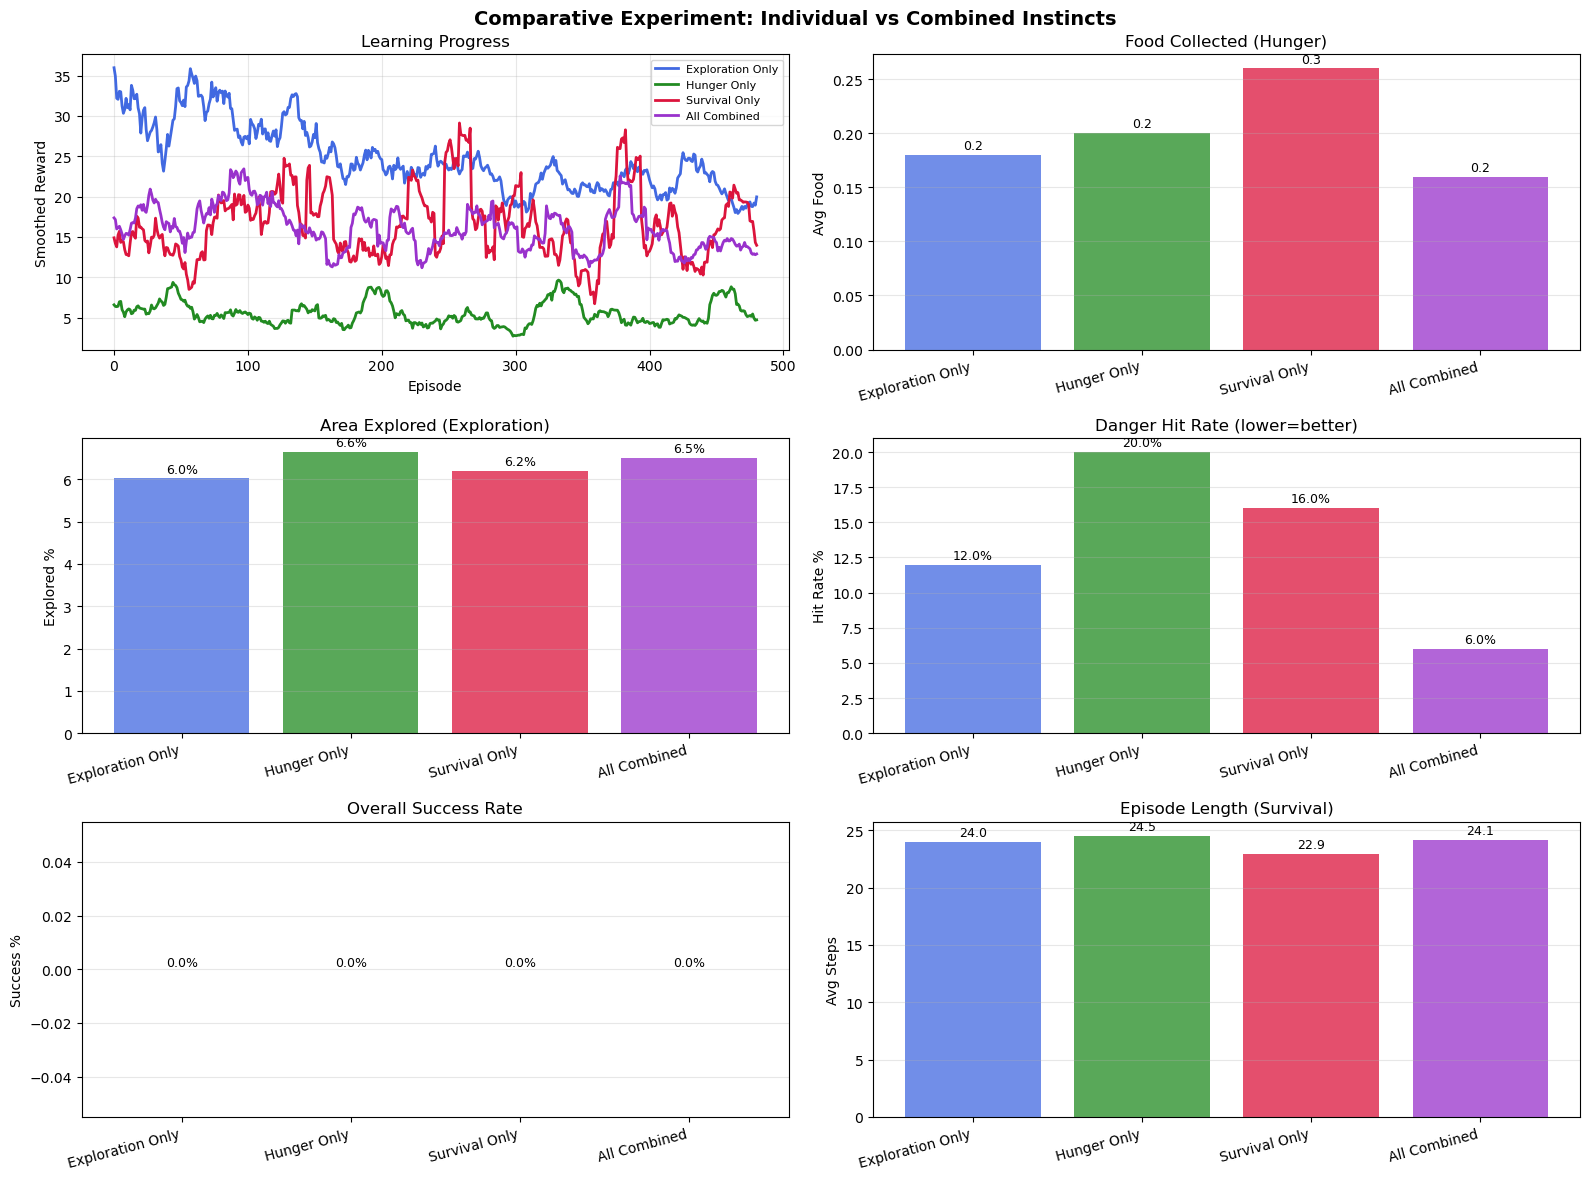


COMPARATIVE RESULTS SUMMARY
Configuration            Reward     Food    Explored%   DangerHit%   Success%
-------------------------------------------------------------------------------------
Exploration Only          20.12     0.18         6.0%        12.0%       0.0%
Hunger Only                6.14     0.20         6.6%        20.0%       0.0%
Survival Only             16.63     0.26         6.2%        16.0%       0.0%
All Combined              13.84     0.16         6.5%         6.0%       0.0%
TRAINING: All Combined (Final)
Weights: {'exploration': 1.0, 'hunger': 1.0, 'survival': 1.0}
  Ep 100: Reward=12.84 | Food=0.3 | Explored=9.3% | DangerHit=42.0% | eps=0.606


  Ep 200: Reward=15.22 | Food=0.3 | Explored=9.3% | DangerHit=20.0% | eps=0.367


  Ep 300: Reward=13.71 | Food=0.2 | Explored=8.1% | DangerHit=24.0% | eps=0.222


  Ep 400: Reward=12.65 | Food=0.1 | Explored=6.6% | DangerHit=24.0% | eps=0.135


  Ep 500: Reward=14.56 | Food=0.1 | Explored=7.1% | DangerHit=16.0% | eps=0.082

Final (All Combined (Final)): Reward=14.56 | Food=0.06 | Explored=7.1% | DangerHit=16.0% | Success=0.0%
Model saved to multi_instinct_agent.pkl


In [ ]:
import numpy as np
import random
from collections import defaultdict
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

# 1. Multi-Instinct Environment
class MultiInstinctEnv(gym.Env):
    """Combined environment supporting all three instincts simultaneously.
    4 channels: agent position, food, dangers, visited cells.
    """

    def __init__(self, grid_size=10, num_food=3, num_dangers=3, num_safe_zones=2):
        super(MultiInstinctEnv, self).__init__()

        self.grid_size = grid_size
        self.num_food = num_food
        self.num_dangers = num_dangers
        self.num_safe_zones = num_safe_zones

        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Box(
            low=0, high=1,
            shape=(grid_size, grid_size, 4),
            dtype=np.float32
        )

        self.reset()

    def reset(self):
        self.grid = np.zeros((self.grid_size, self.grid_size, 4))

        self.agent_pos = np.random.randint(0, self.grid_size, size=2)
        self.grid[self.agent_pos[0], self.agent_pos[1], 0] = 1

        # Place food
        self.food_positions = []
        for _ in range(self.num_food):
            pos = np.random.randint(0, self.grid_size, size=2)
            while np.array_equal(pos, self.agent_pos):
                pos = np.random.randint(0, self.grid_size, size=2)
            self.food_positions.append(pos)
            self.grid[pos[0], pos[1], 1] = 1

        # Place dangers
        self.danger_positions = []
        for _ in range(self.num_dangers):
            pos = np.random.randint(0, self.grid_size, size=2)
            while (np.array_equal(pos, self.agent_pos) or
                   any(np.array_equal(pos, f) for f in self.food_positions)):
                pos = np.random.randint(0, self.grid_size, size=2)
            self.danger_positions.append(pos)
            self.grid[pos[0], pos[1], 2] = 1

        # Place safe zones
        self.safe_zone_positions = []
        for _ in range(self.num_safe_zones):
            pos = np.random.randint(0, self.grid_size, size=2)
            while (np.array_equal(pos, self.agent_pos) or
                   any(np.array_equal(pos, f) for f in self.food_positions) or
                   any(np.array_equal(pos, d) for d in self.danger_positions)):
                pos = np.random.randint(0, self.grid_size, size=2)
            self.safe_zone_positions.append(pos)

        # Visited tracking
        self.visited = np.zeros((self.grid_size, self.grid_size))
        self.visited[self.agent_pos[0], self.agent_pos[1]] = 1
        self.grid[:, :, 3] = self.visited

        # Energy
        self.energy = 1.0
        self.energy_decay = 0.04
        self.energy_gain = 0.3

        # Stats
        self.steps = 0
        self.food_collected = 0
        self.unique_cells = 1
        self.hit_danger = False
        self.safe_zones_visited = 0

        return self.grid.copy()

    def step(self, action):
        old_pos = self.agent_pos.copy()

        if action == 0 and self.agent_pos[0] > 0:
            self.agent_pos[0] -= 1
        elif action == 1 and self.agent_pos[0] < self.grid_size - 1:
            self.agent_pos[0] += 1
        elif action == 2 and self.agent_pos[1] > 0:
            self.agent_pos[1] -= 1
        elif action == 3 and self.agent_pos[1] < self.grid_size - 1:
            self.agent_pos[1] += 1

        self.grid[old_pos[0], old_pos[1], 0] = 0
        self.grid[self.agent_pos[0], self.agent_pos[1], 0] = 1

        self.energy = max(0.0, self.energy - self.energy_decay)

        # Check food
        food_this_step = 0
        for i, food_pos in enumerate(self.food_positions):
            if np.array_equal(self.agent_pos, food_pos):
                food_this_step += 1
                self.food_collected += 1
                self.energy = min(1.0, self.energy + 0.2)
                self.grid[food_pos[0], food_pos[1], 1] = 0
                new_pos = np.random.randint(0, self.grid_size, size=2)
                while (self.grid[new_pos[0], new_pos[1], 0] == 1 or
                       self.grid[new_pos[0], new_pos[1], 2] == 1):
                    new_pos = np.random.randint(0, self.grid_size, size=2)
                self.food_positions[i] = new_pos
                self.grid[new_pos[0], new_pos[1], 1] = 1
                break

        # Check safe zone
        at_safe_zone = False
        for sz_pos in self.safe_zone_positions:
            if np.array_equal(self.agent_pos, sz_pos):
                self.energy = min(1.0, self.energy + self.energy_gain)
                self.safe_zones_visited += 1
                at_safe_zone = True
                break

        # Check danger
        self.hit_danger = False
        for d_pos in self.danger_positions:
            if np.array_equal(self.agent_pos, d_pos):
                self.hit_danger = True
                break

        # Track visited
        if not self.visited[self.agent_pos[0], self.agent_pos[1]]:
            self.visited[self.agent_pos[0], self.agent_pos[1]] = 1
            self.unique_cells += 1
        self.grid[:, :, 3] = self.visited

        self.steps += 1
        done = self.hit_danger or self.energy <= 0 or self.steps >= 80

        return self.grid.copy(), 0.0, done, {
            'steps': self.steps,
            'food_collected': self.food_collected,
            'food_this_step': food_this_step,
            'unique_cells': self.unique_cells,
            'energy': self.energy,
            'hit_danger': self.hit_danger,
            'at_safe_zone': at_safe_zone,
            'safe_zones_visited': self.safe_zones_visited,
            'exploration_pct': self.unique_cells / (self.grid_size * self.grid_size)
        }

    def render(self, mode='human'):
        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        titles = ['Agent', 'Food', 'Danger', 'Visited']
        cmaps = ['viridis', 'Greens', 'Reds', 'Blues']
        for i, ax in enumerate(axes):
            ax.imshow(self.grid[:, :, i], cmap=cmaps[i])
            ax.set_title(titles[i])
            ax.set_xticks([])
            ax.set_yticks([])
        plt.suptitle(f'Step: {self.steps} | Food: {self.food_collected} | '
                     f'Explored: {self.unique_cells}/{self.grid_size**2} | '
                     f'Energy: {self.energy:.2f} | Danger: {self.hit_danger}')
        plt.tight_layout()
        plt.show()


# 2. Multi-Instinct Agent
class MultiInstinctAgent:
    """Q-learning agent combining exploration, hunger, and survival instincts.
    instinct_weights controls how much each sub-reward contributes.
    Set a weight to 0.0 to disable that instinct entirely.
    """

    def __init__(self, state_shape, num_actions,
                 learning_rate=0.15, discount_factor=0.97,
                 exploration_rate=1.0, exploration_decay=0.995,
                 instinct_weights=None):

        self.state_shape = state_shape
        self.num_actions = num_actions
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate
        self.exploration_decay = exploration_decay
        self.min_exploration_rate = 0.05

        self.instinct_weights = instinct_weights or {'exploration': 1.0, 'hunger': 1.0, 'survival': 1.0}

        self.q_table = defaultdict(lambda: np.zeros(num_actions))
        self.training_history = []

        self.last_food_count = 0
        self.last_unique_cells = 0

    def state_to_key(self, state, energy):
        """Compact state key combining all three instinct perspectives."""
        agent_pos = np.argwhere(state[:, :, 0] == 1)[0]

        # Nearest food position
        food_positions = np.argwhere(state[:, :, 1] == 1)
        if len(food_positions) > 0:
            dists = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in food_positions]
            nf = food_positions[np.argmin(dists)]
            food_key = f"{nf[0]},{nf[1]}"
        else:
            food_key = "none"

        # Two nearest danger positions
        danger_positions = np.argwhere(state[:, :, 2] == 1)
        if len(danger_positions) > 0:
            dists = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in danger_positions]
            idx = np.argsort(dists)[:2]
            danger_key = ",".join([f"{danger_positions[i][0]},{danger_positions[i][1]}" for i in idx])
        else:
            danger_key = "none"

        # 3x3 local visited pattern
        visited = state[:, :, 3]
        local = []
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                x, y = agent_pos[0] + dx, agent_pos[1] + dy
                if 0 <= x < state.shape[0] and 0 <= y < state.shape[1]:
                    local.append(str(int(visited[x, y])))
                else:
                    local.append('1')

        energy_band = int(energy * 5)
        return f"{agent_pos[0]},{agent_pos[1]}|{food_key}|{danger_key}|{''  .join(local)}|e{energy_band}"

    def choose_action(self, state, energy):
        state_key = self.state_to_key(state, energy)
        if random.random() < self.exploration_rate:
            return random.randint(0, self.num_actions - 2)
        return np.argmax(self.q_table[state_key])

    def _exploration_reward(self, env, action, info):
        reward = 0.0
        if info['unique_cells'] > self.last_unique_cells:
            reward += 2.0
        self.last_unique_cells = info['unique_cells']
        visited = env.grid[:, :, 3]
        agent_pos = np.argwhere(env.grid[:, :, 0] == 1)[0]
        local_new = sum(
            1 for dx in [-1, 0, 1] for dy in [-1, 0, 1]
            if 0 <= agent_pos[0]+dx < env.grid_size and 0 <= agent_pos[1]+dy < env.grid_size
            and visited[agent_pos[0]+dx, agent_pos[1]+dy] == 0
        )
        reward += local_new * 0.1
        if action == 4:
            reward -= 0.3
        return reward

    def _hunger_reward(self, env, action, info):
        reward = 0.0
        if info['food_collected'] > self.last_food_count:
            reward += 5.0
        self.last_food_count = info['food_collected']
        agent_pos = np.argwhere(env.grid[:, :, 0] == 1)[0]
        food_positions = np.argwhere(env.grid[:, :, 1] == 1)
        if len(food_positions) > 0:
            dists = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in food_positions]
            min_dist = min(dists)
            old_pos = agent_pos.copy()
            if action == 0: old_pos[0] += 1
            elif action == 1: old_pos[0] -= 1
            elif action == 2: old_pos[1] += 1
            elif action == 3: old_pos[1] -= 1
            old_min = min(abs(p[0]-old_pos[0]) + abs(p[1]-old_pos[1]) for p in food_positions)
            if min_dist < old_min:
                reward += 0.5
            elif min_dist > old_min:
                reward -= 0.1
        if action == 4 and len(food_positions) > 0:
            reward -= 0.3
        return reward

    def _survival_reward(self, env, action, info):
        reward = 0.5  # alive bonus
        energy = info['energy']
        if energy > 0.6:
            reward += 0.1
        elif energy < 0.3:
            reward -= 0.3
        if info['at_safe_zone']:
            reward += 2.0
        if info['hit_danger']:
            reward -= 10.0
        agent_pos = np.argwhere(env.grid[:, :, 0] == 1)[0]
        danger_positions = np.argwhere(env.grid[:, :, 2] == 1)
        if len(danger_positions) > 0:
            dists = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in danger_positions]
            min_dist = min(dists)
            if min_dist >= 3:
                reward += 0.2
            elif min_dist == 1:
                reward -= 0.4
            old_pos = agent_pos.copy()
            if action == 0: old_pos[0] += 1
            elif action == 1: old_pos[0] -= 1
            elif action == 2: old_pos[1] += 1
            elif action == 3: old_pos[1] -= 1
            old_min = min(abs(p[0]-old_pos[0]) + abs(p[1]-old_pos[1]) for p in danger_positions)
            if min_dist > old_min:
                reward += 0.3
            elif min_dist < old_min:
                reward -= 0.15
        return reward

    def compute_combined_reward(self, env, action, info):
        """Weighted sum of active instinct rewards, normalised by active weight total."""
        w = self.instinct_weights
        exp_r  = self._exploration_reward(env, action, info) if w['exploration'] > 0 else 0.0
        hun_r  = self._hunger_reward(env, action, info)      if w['hunger']      > 0 else 0.0
        surv_r = self._survival_reward(env, action, info)    if w['survival']    > 0 else 0.0

        total = w['exploration']*exp_r + w['hunger']*hun_r + w['survival']*surv_r
        weight_sum = sum(v for v in w.values() if v > 0)
        if weight_sum > 0:
            total /= weight_sum

        return total, exp_r, hun_r, surv_r

    def learn(self, state, energy, action, reward, next_state, next_energy, done):
        sk  = self.state_to_key(state, energy)
        nsk = self.state_to_key(next_state, next_energy)
        cq  = self.q_table[sk][action]
        target = reward if done else reward + self.discount_factor * np.max(self.q_table[nsk])
        self.q_table[sk][action] = cq + self.learning_rate * (target - cq)
        if done:
            self.exploration_rate = max(self.min_exploration_rate,
                                        self.exploration_rate * self.exploration_decay)

    def train_episode(self, env, max_steps=80):
        state = env.reset()
        self.last_food_count = 0
        self.last_unique_cells = 0
        total_reward = 0
        steps = 0

        for step in range(max_steps):
            energy = env.energy
            action = self.choose_action(state, energy)
            next_state, _, done, info = env.step(action)
            next_energy = env.energy

            combined_r, exp_r, hun_r, surv_r = self.compute_combined_reward(env, action, info)
            self.learn(state, energy, action, combined_r, next_state, next_energy, done)

            total_reward += combined_r
            state = next_state
            steps = step + 1
            if done:
                break

        success = (not info['hit_danger'] and info['energy'] > 0
                   and info['food_collected'] > 0 and info['steps'] >= 20)

        self.training_history.append({
            'total_reward': total_reward,
            'steps': steps,
            'exploration_rate': self.exploration_rate,
            'food_collected': info['food_collected'],
            'unique_cells': info['unique_cells'],
            'energy': info['energy'],
            'hit_danger': info['hit_danger'],
            'safe_zones_visited': info['safe_zones_visited'],
            'exploration_pct': info['exploration_pct'],
            'success': 1 if success else 0
        })

        return total_reward, steps

    def get_performance_metrics(self, last_n=50):
        if len(self.training_history) < last_n:
            last_n = len(self.training_history)
        recent = self.training_history[-last_n:]
        return {
            'avg_reward':          np.mean([h['total_reward']     for h in recent]),
            'avg_food':            np.mean([h['food_collected']    for h in recent]),
            'avg_cells':           np.mean([h['unique_cells']      for h in recent]),
            'avg_steps':           np.mean([h['steps']             for h in recent]),
            'success_rate':        np.mean([h['success']           for h in recent]) * 100,
            'danger_hit_rate':     np.mean([h['hit_danger']        for h in recent]) * 100,
            'avg_exploration_pct': np.mean([h['exploration_pct']   for h in recent]) * 100,
        }

    def save_model(self, filename):
        import pickle
        with open(filename, 'wb') as f:
            pickle.dump(dict(self.q_table), f)
        print(f"Model saved to {filename}")

    def load_model(self, filename):
        import pickle
        with open(filename, 'rb') as f:
            loaded = pickle.load(f)
            self.q_table = defaultdict(lambda: np.zeros(self.num_actions), loaded)
        print(f"Model loaded from {filename}")


# 3. Single-Configuration Training
def train_multi_instinct_agent(instinct_weights, num_episodes=500,
                                label="Combined", show_progress=True):
    """Train one MultiInstinctAgent with given weights."""
    env = MultiInstinctEnv(grid_size=10, num_food=3, num_dangers=3, num_safe_zones=2)
    agent = MultiInstinctAgent(
        state_shape=env.observation_space.shape,
        num_actions=env.action_space.n,
        learning_rate=0.15, discount_factor=0.97,
        exploration_rate=1.0, exploration_decay=0.995,
        instinct_weights=instinct_weights
    )

    print("=" * 60)
    print(f"TRAINING: {label}")
    print(f"Weights: {instinct_weights}")
    print("=" * 60)

    episode_rewards = []
    for episode in range(num_episodes):
        reward, _ = agent.train_episode(env)
        episode_rewards.append(reward)
        if show_progress and (episode + 1) % 100 == 0:
            m = agent.get_performance_metrics(50)
            print(f"  Ep {episode+1}: Reward={m['avg_reward']:.2f} | "
                  f"Food={m['avg_food']:.1f} | "
                  f"Explored={m['avg_exploration_pct']:.1f}% | "
                  f"DangerHit={m['danger_hit_rate']:.1f}% | "
                  f"eps={agent.exploration_rate:.3f}")

    m = agent.get_performance_metrics(50)
    print(f"\nFinal ({label}): Reward={m['avg_reward']:.2f} | Food={m['avg_food']:.2f} | "
          f"Explored={m['avg_exploration_pct']:.1f}% | DangerHit={m['danger_hit_rate']:.1f}% | "
          f"Success={m['success_rate']:.1f}%")
    return agent, env, episode_rewards


# 4. Comparative Experiment Runner
def run_comparative_experiments(num_episodes=500):
    """Train all four instinct configurations and return results for comparison."""

    configs = [
        ({'exploration': 1.0, 'hunger': 0.0, 'survival': 0.0}, "Exploration Only"),
        ({'exploration': 0.0, 'hunger': 1.0, 'survival': 0.0}, "Hunger Only"),
        ({'exploration': 0.0, 'hunger': 0.0, 'survival': 1.0}, "Survival Only"),
        ({'exploration': 1.0, 'hunger': 1.0, 'survival': 1.0}, "All Combined"),
    ]

    results = {}
    for weights, label in configs:
        print(f"\n{'='*60}\nRunning: {label}\n{'='*60}")
        agent, env, rewards = train_multi_instinct_agent(
            weights, num_episodes, label, show_progress=False)
        results[label] = {
            'agent':   agent,
            'rewards': rewards,
            'metrics': agent.get_performance_metrics(50)
        }
        m = results[label]['metrics']
        print(f"  => Reward={m['avg_reward']:.2f} | Food={m['avg_food']:.1f} | "
              f"Explored={m['avg_exploration_pct']:.1f}% | "
              f"DangerHit={m['danger_hit_rate']:.1f}% | Success={m['success_rate']:.1f}%")

    return results


# 5. Visualization
def visualize_comparative_results(results):
    """Side-by-side comparison plots and summary table."""
    labels = list(results.keys())
    colors = ['royalblue', 'forestgreen', 'crimson', 'darkorchid']
    window = 20

    plt.figure(figsize=(16, 12))

    # Learning curves
    plt.subplot(3, 2, 1)
    for label, color in zip(labels, colors):
        rewards = results[label]['rewards']
        if len(rewards) > window:
            sm = np.convolve(rewards, np.ones(window)/window, mode='valid')
            plt.plot(sm, label=label, color=color, linewidth=2)
        else:
            plt.plot(rewards, label=label, color=color, linewidth=2)
    plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
    plt.title('Learning Progress'); plt.legend(fontsize=8); plt.grid(True, alpha=0.3)

    def bar_chart(ax, key, title, ylabel, pct=False):
        vals = [results[l]['metrics'][key] for l in labels]
        bars = ax.bar(labels, vals, color=colors, alpha=0.75)
        ax.set_title(title); ax.set_ylabel(ylabel)
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=15, ha='right')
        ax.grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, vals):
            suffix = '%' if pct else ''
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                    f'{val:.1f}{suffix}', ha='center', va='bottom', fontsize=9)

    bar_chart(plt.subplot(3, 2, 2), 'avg_food',            'Food Collected (Hunger)',       'Avg Food')
    bar_chart(plt.subplot(3, 2, 3), 'avg_exploration_pct', 'Area Explored (Exploration)',   'Explored %', pct=True)
    bar_chart(plt.subplot(3, 2, 4), 'danger_hit_rate',     'Danger Hit Rate (lower=better)','Hit Rate %', pct=True)
    bar_chart(plt.subplot(3, 2, 5), 'success_rate',        'Overall Success Rate',          'Success %', pct=True)
    bar_chart(plt.subplot(3, 2, 6), 'avg_steps',           'Episode Length (Survival)',     'Avg Steps')

    plt.suptitle('Comparative Experiment: Individual vs Combined Instincts',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Summary table
    print("\n" + "=" * 85)
    print("COMPARATIVE RESULTS SUMMARY")
    print("=" * 85)
    print(f"{'Configuration':<20} {'Reward':>10} {'Food':>8} {'Explored%':>12} {'DangerHit%':>12} {'Success%':>10}")
    print("-" * 85)
    for label in labels:
        m = results[label]['metrics']
        print(f"{label:<20} {m['avg_reward']:>10.2f} {m['avg_food']:>8.2f} "
            f"{m['avg_exploration_pct']:>11.1f}% {m['danger_hit_rate']:>11.1f}% "
            f"{m['success_rate']:>9.1f}%")
    print("=" * 85)


# 6. Main Execution
if __name__ == "__main__":
    results = run_comparative_experiments(num_episodes=500)
    visualize_comparative_results(results)

    # Save the fully combined agent
    combined_agent, env, _ = train_multi_instinct_agent(
        instinct_weights={'exploration': 1.0, 'hunger': 1.0, 'survival': 1.0},
        num_episodes=500, label="All Combined (Final)", show_progress=True
    )
    combined_agent.save_model("multi_instinct_agent.pkl")



Running: Exploration Only
TRAINING (V2 relative encoding): Exploration Only
Weights: {'exploration': 1.0, 'hunger': 0.0, 'survival': 0.0}



Final (Exploration Only): reward=24.02 | food=0.28 | explored=6.5% | danger=28.0% | success=0.0% | states learned=10705
  => reward=24.02 | food=0.28 | explored=6.5% | danger=28.0% | success=0.0%

Running: Hunger Only
TRAINING (V2 relative encoding): Hunger Only
Weights: {'exploration': 0.0, 'hunger': 1.0, 'survival': 0.0}



Final (Hunger Only): reward=6.38 | food=0.28 | explored=7.6% | danger=18.0% | success=0.0% | states learned=14090
  => reward=6.38 | food=0.28 | explored=7.6% | danger=18.0% | success=0.0%

Running: Survival Only
TRAINING (V2 relative encoding): Survival Only
Weights: {'exploration': 0.0, 'hunger': 0.0, 'survival': 1.0}



Final (Survival Only): reward=15.49 | food=0.14 | explored=6.3% | danger=28.0% | success=0.0% | states learned=11202
  => reward=15.49 | food=0.14 | explored=6.3% | danger=28.0% | success=0.0%

Running: All Combined
TRAINING (V2 relative encoding): All Combined
Weights: {'exploration': 1.0, 'hunger': 1.0, 'survival': 1.0}



Final (All Combined): reward=17.59 | food=0.22 | explored=8.0% | danger=18.0% | success=0.0% | states learned=11149
  => reward=17.59 | food=0.22 | explored=8.0% | danger=18.0% | success=0.0%


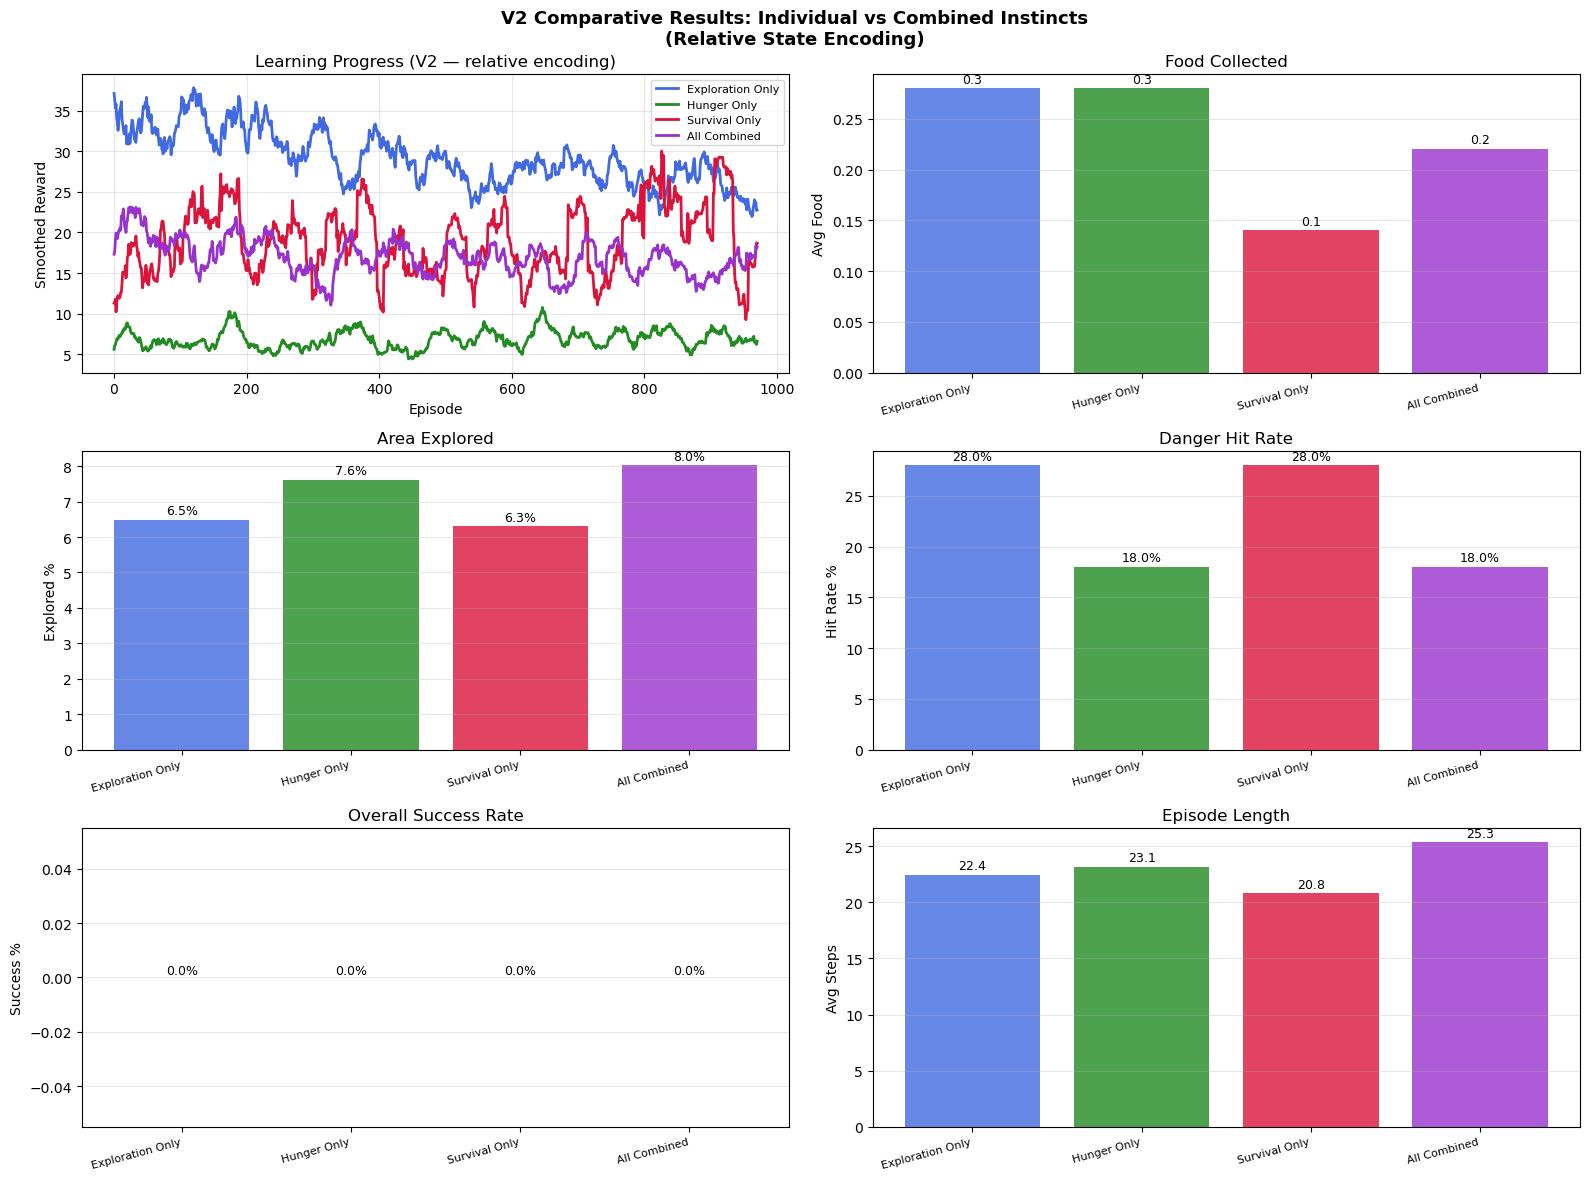


V2 COMPARATIVE RESULTS SUMMARY
Configuration            Reward     Food    Explored%   DangerHit%   Success%   States
-------------------------------------------------------------------------------------
Exploration Only          24.02     0.28         6.5%        28.0%       0.0%    10705
Hunger Only                6.38     0.28         7.6%        18.0%       0.0%    14090
Survival Only             15.49     0.14         6.3%        28.0%       0.0%    11202
All Combined              17.59     0.22         8.0%        18.0%       0.0%    11149


In [ ]:
import numpy as np
import random
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt

# Improved Multi-Instinct Agent with relative state encoding
# Key change: state_to_key uses direction + distance bins instead of
# absolute grid positions, so the agent generalises across locations.

def _rel_key(target_pos, agent_pos):
    """Encode target as (row-direction, col-direction, distance-bin).
    Row direction: -1=above  0=same  +1=below
    Col direction: -1=left   0=same  +1=right
    Distance bin:   1=adjacent(1)  2=close(2-3)  3=far(4+)
    """
    dr = int(target_pos[0]) - int(agent_pos[0])
    dc = int(target_pos[1]) - int(agent_pos[1])
    dist = abs(dr) + abs(dc)

    row_dir = 0 if dr == 0 else (1 if dr > 0 else -1)
    col_dir = 0 if dc == 0 else (1 if dc > 0 else -1)

    if dist <= 1:
        dist_bin = 1
    elif dist <= 3:
        dist_bin = 2
    else:
        dist_bin = 3

    return f"({row_dir},{col_dir},{dist_bin})"


class MultiInstinctAgentV2:
    """Multi-instinct Q-learning agent with relative state encoding.

    Instead of storing absolute food/danger positions in the state key,
    we store direction + distance bin relative to the agent.  This
    reduces the effective state space from O(grid^2) per object to
    O(3 * 3 * 3) = 27 values per object, allowing Q-learning to
    generalise across positions and converge far faster.
    """

    def __init__(self, state_shape, num_actions,
                learning_rate=0.15, discount_factor=0.97,
                exploration_rate=1.0, exploration_decay=0.997,
                instinct_weights=None):

        self.state_shape   = state_shape
        self.num_actions   = num_actions
        self.lr            = learning_rate
        self.gamma         = discount_factor
        self.eps           = exploration_rate
        self.eps_decay     = exploration_decay
        self.eps_min       = 0.05
        self.instinct_weights = instinct_weights or {
            'exploration': 1.0, 'hunger': 1.0, 'survival': 1.0}

        self.q_table       = defaultdict(lambda: np.zeros(num_actions))
        self.training_history = []

        self.last_food_count   = 0
        self.last_unique_cells = 0

    # ------------------------------------------------------------------ #
    # State representation                                                 #
    # ------------------------------------------------------------------ #
    def state_to_key(self, state, energy):
        """Relative state key — no absolute positions, fully generalisable."""
        agent_pos = np.argwhere(state[:, :, 0] == 1)[0]

        # Nearest food: direction + distance
        food_pos = np.argwhere(state[:, :, 1] == 1)
        if len(food_pos) > 0:
            dists     = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in food_pos]
            food_key  = _rel_key(food_pos[np.argmin(dists)], agent_pos)
        else:
            food_key  = "fnone"

        # Two nearest dangers: direction + distance each
        dang_pos = np.argwhere(state[:, :, 2] == 1)
        if len(dang_pos) > 0:
            dists     = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in dang_pos]
            idx       = np.argsort(dists)[:2]
            dang_key  = ",".join(_rel_key(dang_pos[i], agent_pos) for i in idx)
        else:
            dang_key  = "dnone"

        # 3x3 local visited pattern (inherently relative)
        vis = state[:, :, 3]
        local = []
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                x, y = agent_pos[0]+dx, agent_pos[1]+dy
                if 0 <= x < state.shape[0] and 0 <= y < state.shape[1]:
                    local.append(str(int(vis[x, y])))
                else:
                    local.append('1')

        e_band = int(energy * 5)
        return f"{food_key}|{dang_key}|{chr(39).join(local)}|e{e_band}"

    # ------------------------------------------------------------------ #
    # Action selection                                                     #
    # ------------------------------------------------------------------ #
    def choose_action(self, state, energy):
        sk = self.state_to_key(state, energy)
        if random.random() < self.eps:
            return random.randint(0, self.num_actions - 2)
        return int(np.argmax(self.q_table[sk]))

    # ------------------------------------------------------------------ #
    # Sub-reward components (same logic as V1)                            #
    # ------------------------------------------------------------------ #
    def _exploration_reward(self, env, action, info):
        r = 0.0
        if info['unique_cells'] > self.last_unique_cells:
            r += 2.0
        self.last_unique_cells = info['unique_cells']
        vis       = env.grid[:, :, 3]
        agent_pos = np.argwhere(env.grid[:, :, 0] == 1)[0]
        new_neighbours = sum(
            1 for dx in [-1,0,1] for dy in [-1,0,1]
            if 0 <= agent_pos[0]+dx < env.grid_size
            and 0 <= agent_pos[1]+dy < env.grid_size
            and vis[agent_pos[0]+dx, agent_pos[1]+dy] == 0
        )
        r += new_neighbours * 0.15
        if action == 4:
            r -= 0.3
        return r

    def _hunger_reward(self, env, action, info):
        r = 0.0
        if info['food_collected'] > self.last_food_count:
            r += 5.0
        self.last_food_count = info['food_collected']
        agent_pos  = np.argwhere(env.grid[:, :, 0] == 1)[0]
        food_pos   = np.argwhere(env.grid[:, :, 1] == 1)
        if len(food_pos) > 0:
            dists   = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in food_pos]
            min_d   = min(dists)
            old     = agent_pos.copy()
            if action == 0: old[0] += 1
            elif action == 1: old[0] -= 1
            elif action == 2: old[1] += 1
            elif action == 3: old[1] -= 1
            old_d = min(abs(p[0]-old[0]) + abs(p[1]-old[1]) for p in food_pos)
            if min_d < old_d: r += 0.5
            elif min_d > old_d: r -= 0.1
        if action == 4 and len(food_pos) > 0:
            r -= 0.3
        return r

    def _survival_reward(self, env, action, info):
        r = 0.5
        e = info['energy']
        if e > 0.6:   r += 0.1
        elif e < 0.3: r -= 0.3
        if info['at_safe_zone']: r += 2.0
        if info['hit_danger']:   r -= 10.0
        agent_pos  = np.argwhere(env.grid[:, :, 0] == 1)[0]
        dang_pos   = np.argwhere(env.grid[:, :, 2] == 1)
        if len(dang_pos) > 0:
            dists  = [abs(p[0]-agent_pos[0]) + abs(p[1]-agent_pos[1]) for p in dang_pos]
            min_d  = min(dists)
            if min_d >= 3: r += 0.2
            elif min_d == 1: r -= 0.4
            old = agent_pos.copy()
            if action == 0: old[0] += 1
            elif action == 1: old[0] -= 1
            elif action == 2: old[1] += 1
            elif action == 3: old[1] -= 1
            old_d = min(abs(p[0]-old[0]) + abs(p[1]-old[1]) for p in dang_pos)
            if min_d > old_d:   r += 0.3
            elif min_d < old_d: r -= 0.15
        return r

    def compute_combined_reward(self, env, action, info):
        w      = self.instinct_weights
        exp_r  = self._exploration_reward(env, action, info) if w['exploration'] > 0 else 0.0
        hun_r  = self._hunger_reward(env, action, info)      if w['hunger']      > 0 else 0.0
        surv_r = self._survival_reward(env, action, info)    if w['survival']    > 0 else 0.0
        total  = w['exploration']*exp_r + w['hunger']*hun_r + w['survival']*surv_r
        wsum   = sum(v for v in w.values() if v > 0)
        return (total / wsum if wsum > 0 else 0.0), exp_r, hun_r, surv_r

    # ------------------------------------------------------------------ #
    # Learning                                                             #
    # ------------------------------------------------------------------ #
    def learn(self, state, energy, action, reward, next_state, next_energy, done):
        sk  = self.state_to_key(state, energy)
        nsk = self.state_to_key(next_state, next_energy)
        cq  = self.q_table[sk][action]
        tgt = reward if done else reward + self.gamma * np.max(self.q_table[nsk])
        self.q_table[sk][action] = cq + self.lr * (tgt - cq)
        if done:
            self.eps = max(self.eps_min, self.eps * self.eps_decay)

    def train_episode(self, env, max_steps=80):
        state  = env.reset()
        self.last_food_count   = 0
        self.last_unique_cells = 0
        total_r, steps = 0, 0

        for step in range(max_steps):
            energy = env.energy
            action = self.choose_action(state, energy)
            next_state, _, done, info = env.step(action)
            next_energy = env.energy

            cr, *_ = self.compute_combined_reward(env, action, info)
            self.learn(state, energy, action, cr, next_state, next_energy, done)

            total_r += cr
            state    = next_state
            steps    = step + 1
            if done: break

        success = (not info['hit_danger'] and info['energy'] > 0
                and info['food_collected'] > 0 and info['steps'] >= 20)

        self.training_history.append({
            'total_reward':    total_r,
            'steps':           steps,
            'exploration_rate':self.eps,
            'food_collected':  info['food_collected'],
            'unique_cells':    info['unique_cells'],
            'energy':          info['energy'],
            'hit_danger':      info['hit_danger'],
            'safe_zones_visited': info['safe_zones_visited'],
            'exploration_pct': info['exploration_pct'],
            'success':         1 if success else 0,
        })
        return total_r, steps

    def get_performance_metrics(self, last_n=50):
        if len(self.training_history) < last_n:
            last_n = len(self.training_history)
        r = self.training_history[-last_n:]
        return {
            'avg_reward':          np.mean([h['total_reward']     for h in r]),
            'avg_food':            np.mean([h['food_collected']    for h in r]),
            'avg_cells':           np.mean([h['unique_cells']      for h in r]),
            'avg_steps':           np.mean([h['steps']             for h in r]),
            'success_rate':        np.mean([h['success']           for h in r]) * 100,
            'danger_hit_rate':     np.mean([h['hit_danger']        for h in r]) * 100,
            'avg_exploration_pct': np.mean([h['exploration_pct']   for h in r]) * 100,
        }


# ------------------------------------------------------------------ #
# Training / experiment runners (V2)                                  #
# ------------------------------------------------------------------ #
def train_v2_agent(instinct_weights, num_episodes=1000,
                label="V2-Combined", show_progress=True):
    env = MultiInstinctEnv(grid_size=10, num_food=3, num_dangers=3, num_safe_zones=2)
    agent = MultiInstinctAgentV2(
        state_shape=env.observation_space.shape,
        num_actions=env.action_space.n,
        learning_rate=0.15, discount_factor=0.97,
        exploration_rate=1.0, exploration_decay=0.997,
        instinct_weights=instinct_weights,
    )

    print("=" * 60)
    print(f"TRAINING (V2 relative encoding): {label}")
    print(f"Weights: {instinct_weights}")
    print("=" * 60)

    rewards = []
    for ep in range(num_episodes):
        r, _ = agent.train_episode(env)
        rewards.append(r)
        if show_progress and (ep + 1) % 200 == 0:
            m = agent.get_performance_metrics(50)
            print(f"  Ep {ep+1:4d}: reward={m['avg_reward']:6.2f} | "
                f"food={m['avg_food']:.2f} | "
                f"explored={m['avg_exploration_pct']:.1f}% | "
                f"danger={m['danger_hit_rate']:.1f}% | "
                f"success={m['success_rate']:.1f}% | "
                f"eps={agent.eps:.3f} | "
                f"states={len(agent.q_table)}")

    m = agent.get_performance_metrics(50)
    print(f"\nFinal ({label}): reward={m['avg_reward']:.2f} | "
        f"food={m['avg_food']:.2f} | explored={m['avg_exploration_pct']:.1f}% | "
        f"danger={m['danger_hit_rate']:.1f}% | success={m['success_rate']:.1f}% | "
        f"states learned={len(agent.q_table)}")
    return agent, env, rewards


def run_v2_comparative_experiments(num_episodes=2000):
    configs = [
        ({'exploration': 1.0, 'hunger': 0.0, 'survival': 0.0}, "Exploration Only"),
        ({'exploration': 0.0, 'hunger': 1.0, 'survival': 0.0}, "Hunger Only"),
        ({'exploration': 0.0, 'hunger': 0.0, 'survival': 1.0}, "Survival Only"),
        ({'exploration': 1.0, 'hunger': 1.0, 'survival': 1.0}, "All Combined"),
    ]
    results = {}
    for weights, label in configs:
        print(f"\n{'='*60}\nRunning: {label}\n{'='*60}")
        agent, env, rewards = train_v2_agent(weights, num_episodes, label, show_progress=False)
        results[label] = {'agent': agent, 'rewards': rewards,
                        'metrics': agent.get_performance_metrics(50)}
        m = results[label]['metrics']
        print(f"  => reward={m['avg_reward']:.2f} | food={m['avg_food']:.2f} | "
            f"explored={m['avg_exploration_pct']:.1f}% | "
            f"danger={m['danger_hit_rate']:.1f}% | success={m['success_rate']:.1f}%")
    return results


def visualize_v2_results(results):
    labels = list(results.keys())
    colors = ['royalblue', 'forestgreen', 'crimson', 'darkorchid']
    window = 30

    plt.figure(figsize=(16, 12))

    plt.subplot(3, 2, 1)
    for label, color in zip(labels, colors):
        rw = results[label]['rewards']
        sm = np.convolve(rw, np.ones(window)/window, mode='valid') if len(rw)>window else rw
        plt.plot(sm, label=label, color=color, linewidth=2)
    plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
    plt.title('Learning Progress (V2 — relative encoding)')
    plt.legend(fontsize=8); plt.grid(True, alpha=0.3)

    def bar(ax, key, title, ylabel, pct=False):
        vals = [results[l]['metrics'][key] for l in labels]
        bars = ax.bar(labels, vals, color=colors, alpha=0.8)
        ax.set_title(title); ax.set_ylabel(ylabel)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(vals)*0.01,
                    f'{v:.1f}{"%" if pct else ""}',
                    ha='center', va='bottom', fontsize=9)

    bar(plt.subplot(3,2,2), 'avg_food',            'Food Collected',         'Avg Food')
    bar(plt.subplot(3,2,3), 'avg_exploration_pct', 'Area Explored',          'Explored %',  pct=True)
    bar(plt.subplot(3,2,4), 'danger_hit_rate',     'Danger Hit Rate',        'Hit Rate %',  pct=True)
    bar(plt.subplot(3,2,5), 'success_rate',        'Overall Success Rate',   'Success %',   pct=True)
    bar(plt.subplot(3,2,6), 'avg_steps',           'Episode Length',         'Avg Steps')

    plt.suptitle('V2 Comparative Results: Individual vs Combined Instincts\n(Relative State Encoding)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n" + "="*85)
    print("V2 COMPARATIVE RESULTS SUMMARY")
    print("="*85)
    print(f"{'Configuration':<20} {'Reward':>10} {'Food':>8} {'Explored%':>12} {'DangerHit%':>12} {'Success%':>10} {'States':>8}")
    print("-"*85)
    for label in labels:
        m = results[label]['metrics']
        n = len(results[label]['agent'].q_table)
        print(f"{label:<20} {m['avg_reward']:>10.2f} {m['avg_food']:>8.2f} "
              f"{m['avg_exploration_pct']:>11.1f}% {m['danger_hit_rate']:>11.1f}% "
              f"{m['success_rate']:>9.1f}% {n:>8d}")
    print("="*85)


if __name__ == "__main__":
    results_v2 = run_v2_comparative_experiments(num_episodes=1000)
    visualize_v2_results(results_v2)
